In [1]:
from utils import*

In [2]:
def getDirectRns(cpd_id):
    direct_rns = set()
    for rn, cpds in rn2cpds.items():
        if cpd_id in cpds:
            direct_rns.add(rn)
    return direct_rns

In [3]:
# from Leave-One-Out analysis

group1 = ['2005', '4952', '184', '325', '3016', '2003', '2002', '7523', '328', '875', '602', '2486', '212', '4011', '7574', '218', '2004', '304', '7584', '206', '4953', '1', '3997', '7577', '148', '7501', '7579', '2007', '253', '7544', '101', '297', '327', '330', '141', '109', '2492']
first10 = ['2005', '4952', '325', '2003', '2002', '602', '218', '206', '4953', '2007']

In [4]:
# NONE 1000 runs

# df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_folditer_NONE.csv', index_col=0)
# df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)
# df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_folditer_NONE.csv', index_col=0)
# df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rules_folditer_NONE.csv', index_col=0)

In [5]:
# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

In [6]:
rns_scope = list(df_rns_folditer[df_rns_folditer.columns[0]].keys())
len(rns_scope)

7678

# Does fold-complexity of reactions increase over time?

## 1. per rule

In [7]:
# average of 1000 runs
rule2fo_ave = {index: np.mean(df_rules_folditer.loc[index]) for index in df_rules_folditer.index}

In [8]:
rule2numFolds = {}

for k in rule2fo_ave.keys():
    rule2numFolds[k] = len(eval(k)[1])

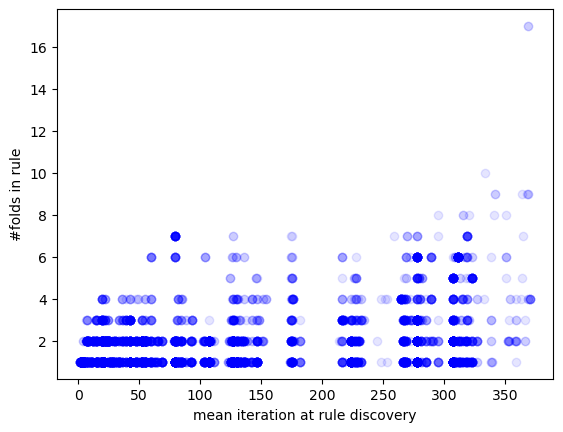

(0.12942262347551936, '1.35E-29')


In [9]:
scatter(rule2fo_ave, rule2numFolds, 'mean iteration at rule discovery', '#folds in rule')
print(spearman(rule2fo_ave, rule2numFolds))

## 2. per reaction

In [10]:
# average of 1000 runs
rn2fo_ave = {index: np.mean(df_rns_folditer.loc[index]) for index in df_rns_folditer.index}

In [11]:
rn2numFoldsMax = {}
rn2numFoldsAll = {}

for rn, rules in rn2rules.items():
    lens = [len(rule) for rule in rules]
    rn2numFoldsMax[rn] = max(lens)
    
    foldset = set()
    for rule in rules:
        for fold in rule:
            foldset.add(fold)
    rn2numFoldsAll[rn] = len(foldset)

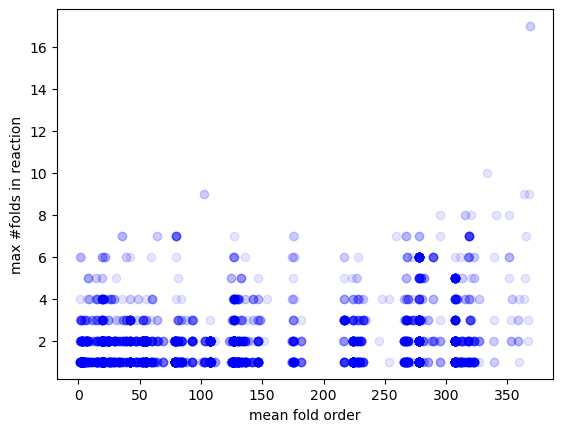

(0.02495068025761786, '5.89E-02')


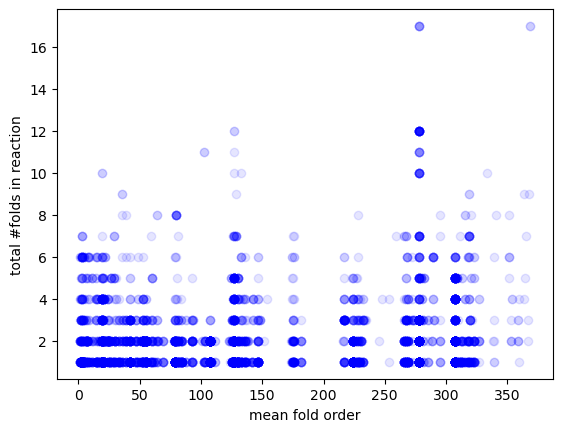

(-0.019302466822657235, '1.44E-01')


In [12]:
scatter(rn2fo_ave, rn2numFoldsMax, 'mean fold order', 'max #folds in reaction')
print(spearman(rn2fo_ave, rn2numFoldsMax))

scatter(rn2fo_ave, rn2numFoldsAll, 'mean fold order', 'total #folds in reaction')
print(spearman(rn2fo_ave, rn2numFoldsAll))

# Draw a single ne trajectory

## find fastest & slowset runs

In [13]:
fo2cpds_list = []
for run in df_cpds_folditer.columns:
    fo2cpds = {}
    for c, order in df_cpds_folditer[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list.append(fo2cpds)
    
fo2cpdNum_list = []
for run in fo2cpds_list:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list.append(fo2cpdNum)

In [14]:
# fastest run

max_area = [0, 0]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
print(max_area)
print(f"fastest seed: {df_cpds_folditer.columns[max_area[0]]}")

[257, 895196]
fastest seed: 37860


In [15]:
min_area = [0, 100000000]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area < min_area[1]:
        min_area = [index, area]
    index += 1
print(min_area)
print(f"slowest seed: {df_cpds_folditer.columns[min_area[0]]}")

[453, 845857]
slowest seed: 46652


## draw fastest run

In [16]:
# ATP pre-exp fastest run
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-09-27_13-49-38_no_lookahead_preExpansion_C00002_37860.pkl.gz')

## plot cumiter

612
851


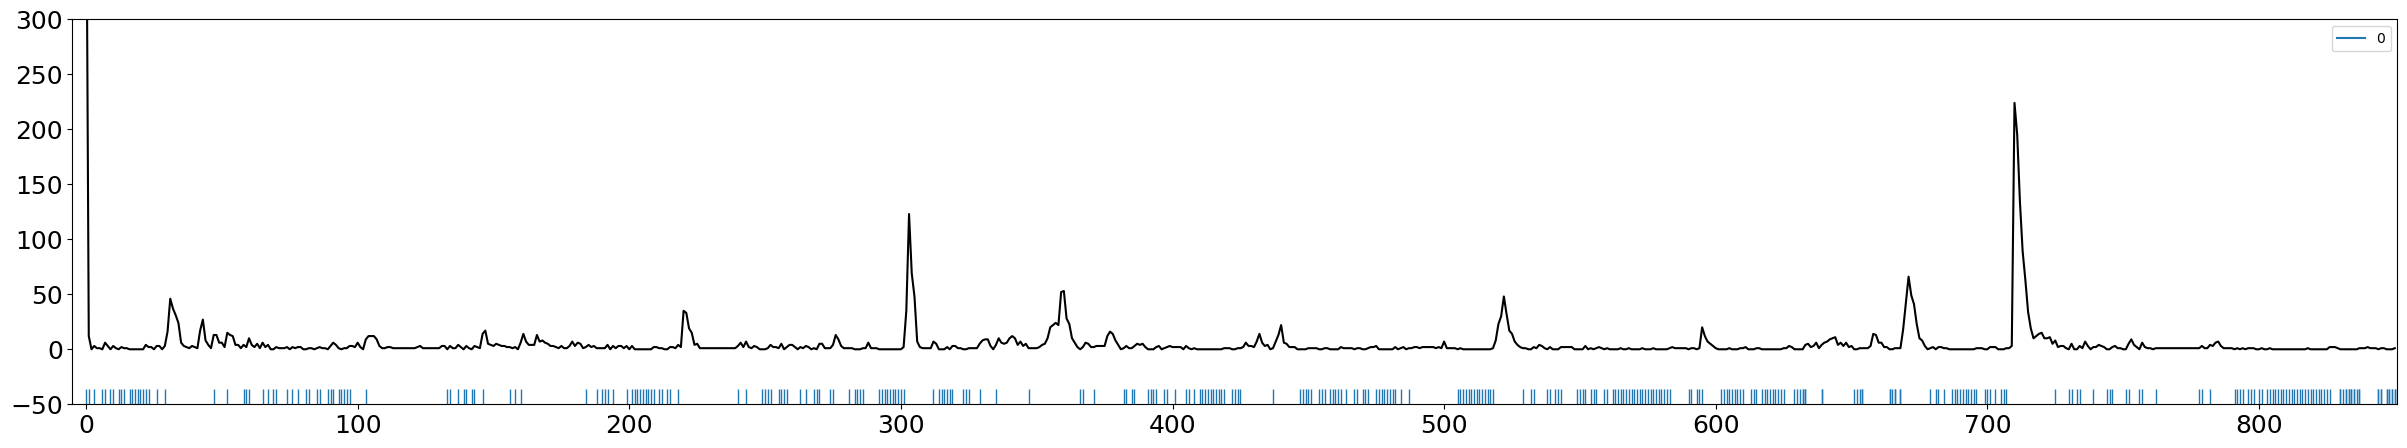

In [17]:
cumiter2cpd = {}
for c, order in result.cpds_cumiter.items():
    if order not in cumiter2cpd.keys():
        cumiter2cpd[order] = [c]
    else:
        cumiter2cpd[order].append(c)
print(len(cumiter2cpd))

cumiter2cpdNum = {}
for fold in cumiter2cpd.keys():
    cumiter2cpdNum[fold] = len(cumiter2cpd[fold])

cumiter2cpdNumFull = {}
for i in range(0, max(cumiter2cpd.keys())):
    if i not in cumiter2cpdNum.keys():
        cumiter2cpdNumFull[i] = 0
    else:
        cumiter2cpdNumFull[i] = cumiter2cpdNum[i]
print(len(cumiter2cpdNumFull))

plt.figure(figsize=(30, 5))
plt.plot(cumiter2cpdNumFull.values(), color='k')

# plot where fold injections happen
sns.rugplot(result.folds_cumiter.values(), height=0.04, color='blue')  # double fold injection

plt.xlim([-5, len(cumiter2cpdNumFull)])
plt.ylim([-50, 300])
plt.xticks(fontsize='18')
plt.yticks(fontsize='18')
# plt.savefig('cumiter_rugplot.svg', dpi=300, bbox_inches='tight')
plt.show()

## plot folditer

In [18]:
folditer2cpd = {}
for c, order in result.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
print(len(folditer2cpdNumFull))

164
361


In [19]:
folditer2folds = {}
for fold, folditer in result.folds_folditer.items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)
print(len(folditer2folds))
        
double_injection = []
triple_injection = []
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        double_injection.append(i)
    if len(folds) == 3:
        triple_injection.append(i)
        
# extend end until all injections complete
for i in range(len(folditer2folds) - len(folditer2cpdNumFull)):
    folditer2cpdNumFull[len(folditer2cpdNumFull)] = 0
print(len(folditer2cpdNumFull))

372
372


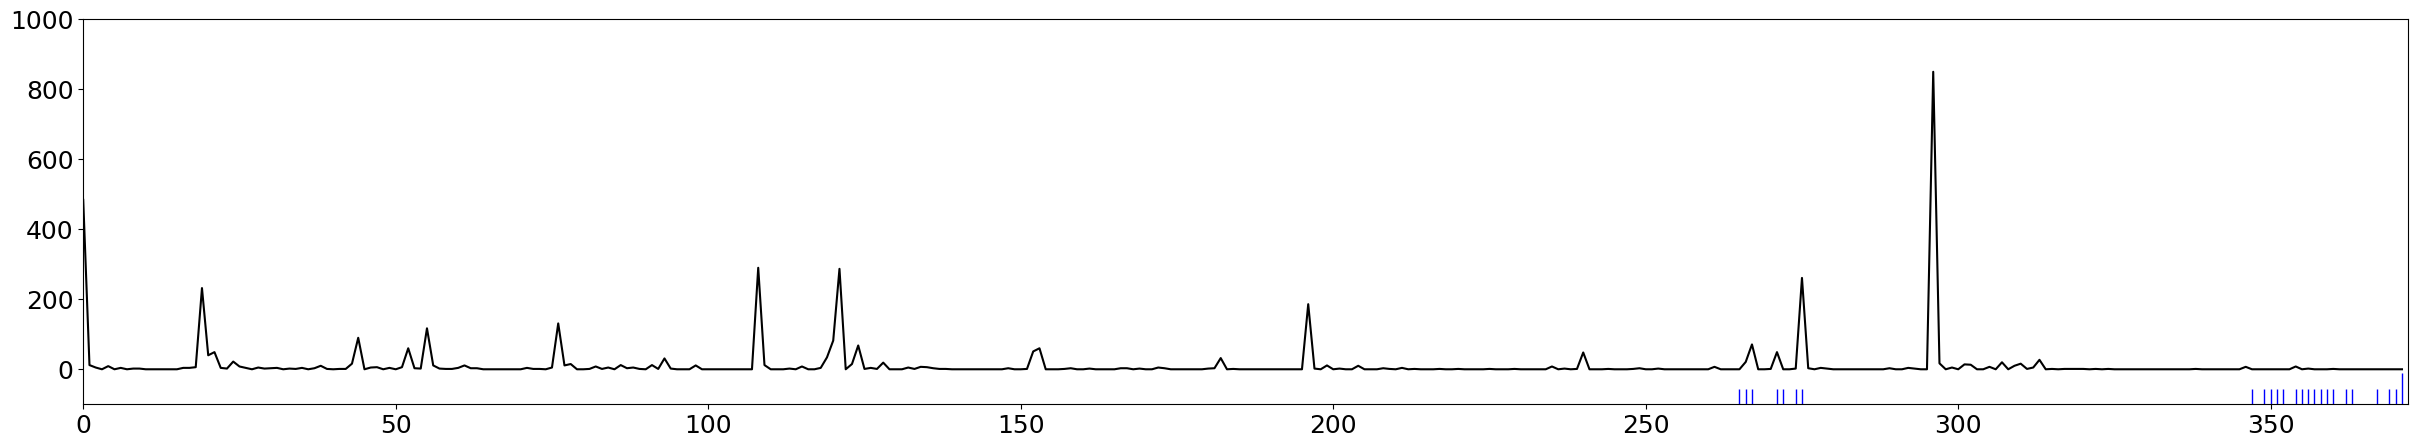

In [20]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
plt.xticks(fontsize='18')
plt.yticks(fontsize='18')
# plt.savefig('folditer_cpds.svg', dpi=300, bbox_inches='tight')
plt.show()

### annotate cpds

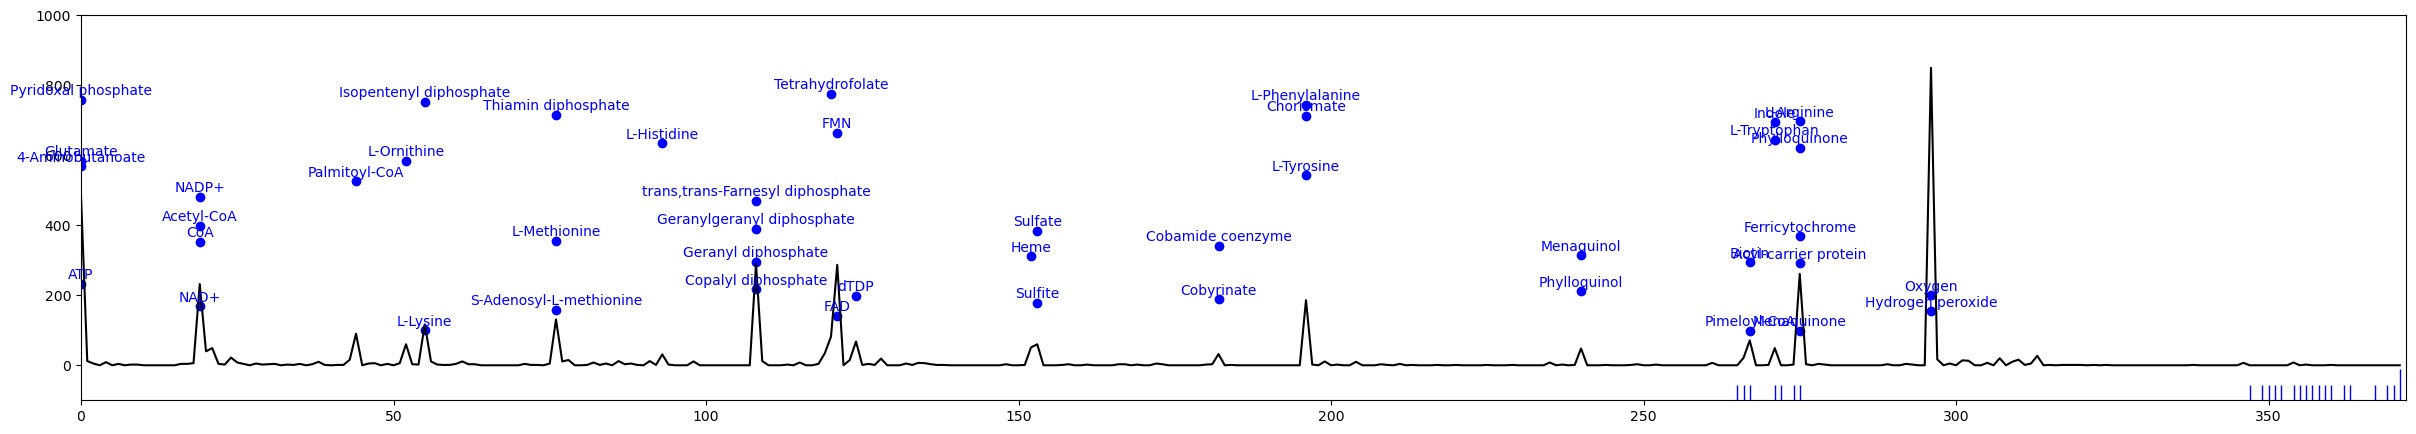

In [21]:
cpd2iter = {}

for cpd in ['C00006', 'C00154', 'C00077', 'C00047', 'C00135', 'C00073', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, 372])
plt.ylim([-100, 1000])
# plt.savefig('folditer_cpds_annotated_2.svg', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# some peaks need further annotation?

cpd2rn = csv2dict('../data/assets/cpd2rn.csv')

In [23]:
for i, cpds in folditer2cpd.items():
    if len(cpds) > 30:
        print(i, len(cpds))

0 484
19 232
20 40
21 49
44 90
52 60
55 117
76 131
93 31
108 290
119 34
120 82
121 287
124 68
152 51
153 60
182 32
196 186
240 48
267 71
271 49
275 261
296 850


In [24]:
import requests
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from PIL import Image

def get_kegg_compound_smiles(kegg_id):
    url = f'http://rest.kegg.jp/get/{kegg_id}/mol'
    response = requests.get(url)
    if response.status_code == 200:
        mol_data = response.text
        mol = Chem.MolFromMolBlock(mol_data)
        return mol
    else:
        raise ValueError(f"Error fetching data for {kegg_id}: {cpd2name.get(kegg_id, '')}")

def draw_multiple_molecules(molecules, mol_labels=None):
    img = Draw.MolsToGridImage(molecules, molsPerRow=10, subImgSize=(400, 400), legends=mol_labels, maxMols=200)
    display(img)

    with open('cpds.png', mode='wb') as f:
        f.write(img.data)
        
def drawMols(molecule_kegg_ids):
    molecules = []
    labels = []

    # from SMILES
    for kegg_id in molecule_kegg_ids:
        try:
            mol_kegg = get_kegg_compound_smiles(kegg_id)
            if mol_kegg:
                molecules.append(mol_kegg)
                labels.append(cpd2name[kegg_id])
        except ValueError as e:
            print(e)
            
    if molecules:
        draw_multiple_molecules(molecules, labels)

In [25]:
# drawMols(folditer2cpd[195])

In [26]:
# how many -CoA cpds are there?

CoA_cpds = set()
for cid, name in cpd2name.items():
    if 'CoA' in name:
        CoA_cpds.add(cid)
print(len(CoA_cpds))  # all CoA cpds in KEGG
print(len(CoA_cpds & set(df_cpds_folditer.index)))  # CoA cpds in our runs

400
216


In [27]:
aa = ['C00037', 'C00077', 'C00041', 'C00097', 'C00049', 'C00025', 'C00079', 'C00135', 'C00407', 'C00047', 'C00123', 'C00073', 'C00152', 'C00148', 'C00064', 'C00062', 'C00065', 'C00188', 'C00183', 'C00078', 'C00082']

In [28]:
for a in aa:
    print(a, cpd2name[a])

C00037 Glycine
C00077 L-Ornithine
C00041 L-Alanine
C00097 L-Cysteine
C00049 L-Aspartate
C00025 L-Glutamate
C00079 L-Phenylalanine
C00135 L-Histidine
C00407 L-Isoleucine
C00047 L-Lysine
C00123 L-Leucine
C00073 L-Methionine
C00152 L-Asparagine
C00148 L-Proline
C00064 L-Glutamine
C00062 L-Arginine
C00065 L-Serine
C00188 L-Threonine
C00183 L-Valine
C00078 L-Tryptophan
C00082 L-Tyrosine


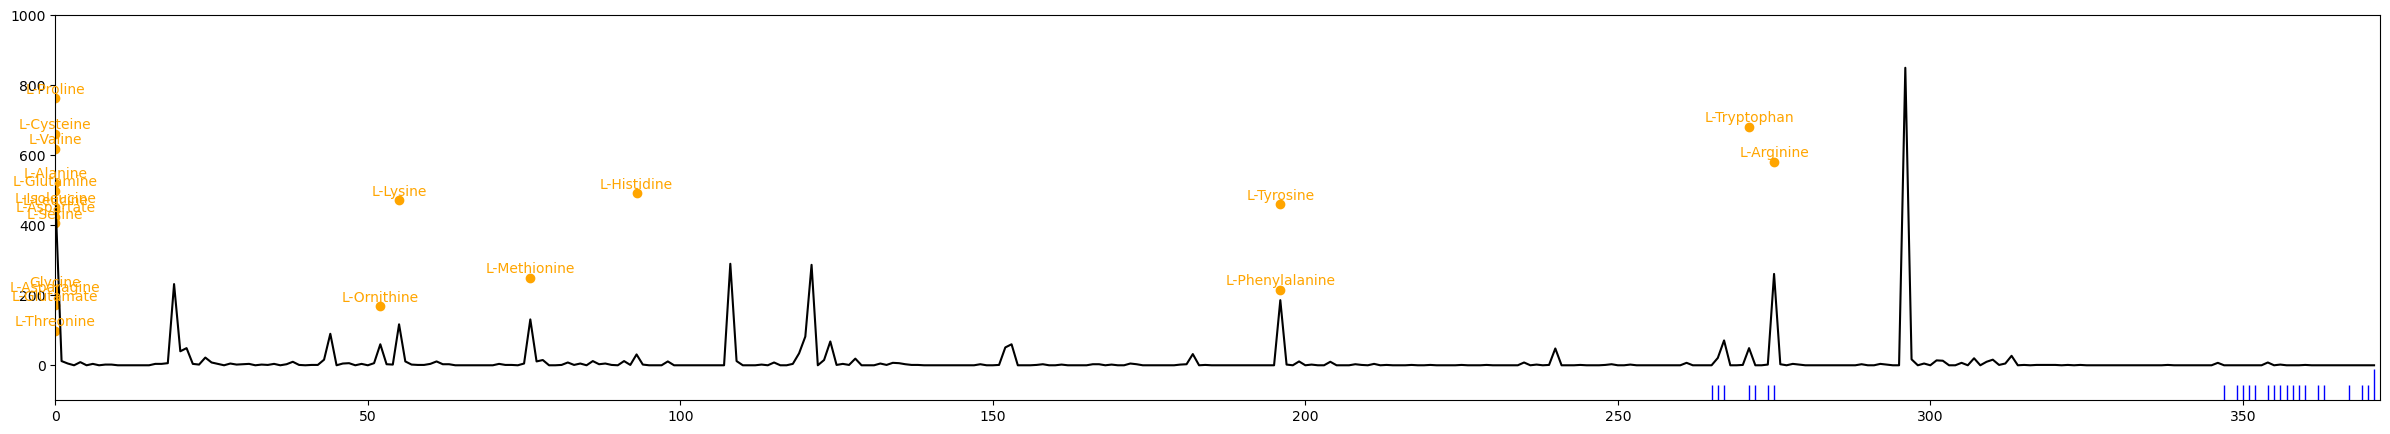

In [29]:
aa2iter = {}
for a in aa:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if a == c:
                aa2iter[a] = folditer   
    
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

# Add annotations
for key, value in aa2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 372])
plt.ylim([-100, 1000])
# plt.savefig('folditer_aas_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

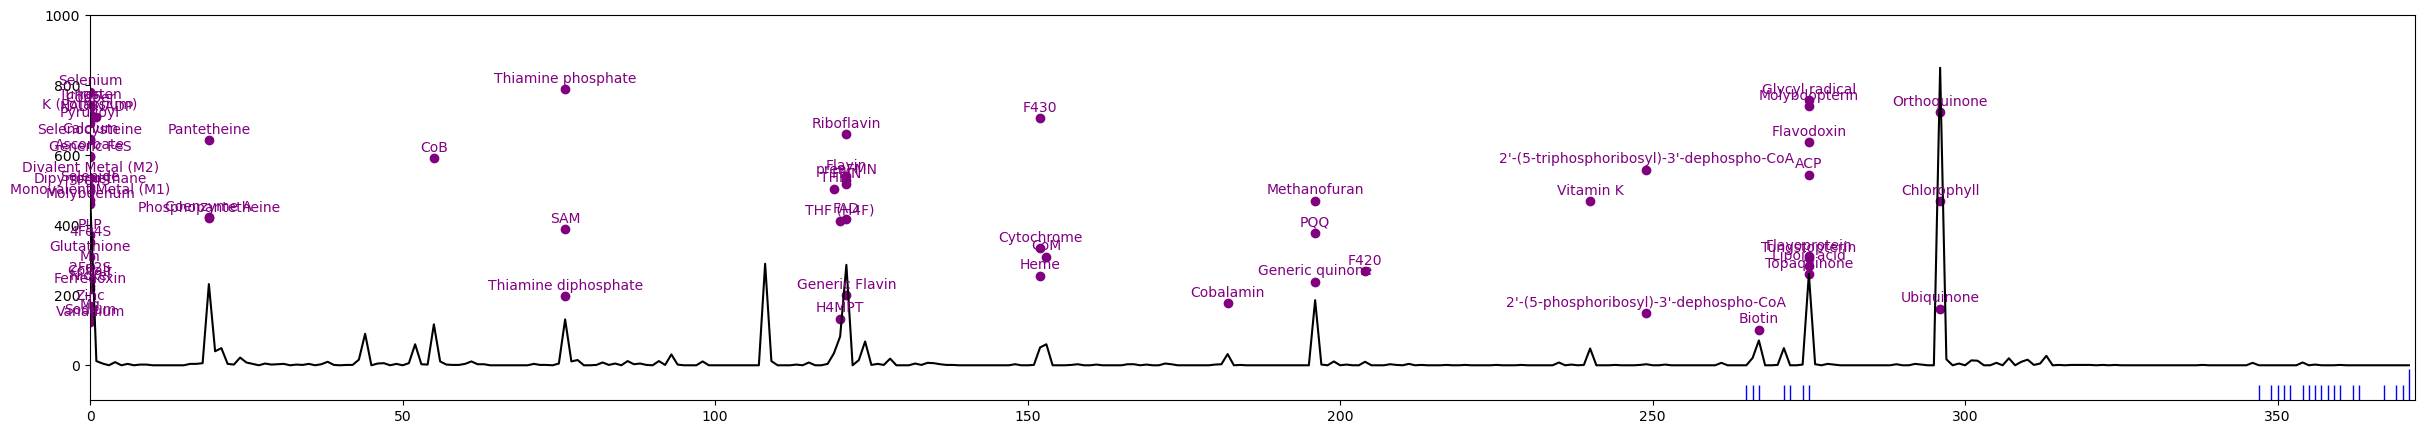

In [30]:
# Z compounds

cpd2iterZ = {}

for folditer in folditer2cpd.keys():
    for c in folditer2cpd[folditer]:
        if c.startswith('Z'):
            cpd2iterZ[c] = folditer
            
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iterZ.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='purple')
    plt.scatter(value, position-10, color='purple')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, 372])
plt.ylim([-100, 1000])
# plt.savefig('folditer_cpds_Z_annotated.svg.svg', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
for cpd, name in cpd2name.items():
    if 'CoA' in name:
        print(cpd, name)

C00010 CoA
C00024 Acetyl-CoA
C00040 Acyl-CoA
C00083 Malonyl-CoA
C00091 Succinyl-CoA
C00100 Propanoyl-CoA
C00136 Butanoyl-CoA
C00154 Palmitoyl-CoA
C00223 p-Coumaroyl-CoA
C00264 3-Oxoacyl-CoA
C00313 Oxalyl-CoA
C00323 Caffeoyl-CoA
C00332 Acetoacetyl-CoA
C00356 (S)-3-Hydroxy-3-methylglutaryl-CoA
C00406 Feruloyl-CoA
C00411 Sinapoyl-CoA
C00412 Stearoyl-CoA
C00510 Oleoyl-CoA
C00512 Benzoyl-CoA
C00527 Glutaryl-CoA
C00531 Itaconyl-CoA
C00540 Cinnamoyl-CoA
C00566 (3S)-Citryl-CoA
C00582 Phenylacetyl-CoA
C00605 2,3-Dehydroacyl-CoA
C00630 2-Methylpropanoyl-CoA
C00640 (3S)-3-Hydroxyacyl-CoA
C00658 trans-2,3-Dehydroacyl-CoA
C00683 (S)-Methylmalonyl-CoA
C00798 Formyl-CoA
C00827 Lactoyl-CoA
C00845 2-Furoyl-CoA
C00877 Crotonoyl-CoA
C00882 Dephospho-CoA
C00888 Pentanoyl-CoA
C00894 Propenoyl-CoA
C00904 Citramalyl-CoA
C00920 CoA-glutathione
C01011 (3S)-Citramalyl-CoA
C01033 2-Methylbutanoyl-CoA
C01063 Pimeloyl-CoA
C01086 (3R)-3-Hydroxyacyl-CoA
C01122 cis-2,3-Dehydroacyl-CoA
C01139 [Acetyl-CoA carboxylase]


In [32]:
for z in cpd2iterZ.keys():
    print(z, cpd2name[z])

Z00054 Zinc
Z00001 2Fe2S
Z00016 Ferredoxin
Z00062 Vanadium
Z00044 Selenocysteine
Z00035 PLP
Z00034 Nickel
Z00023 Glutathione
Z00060 Monovalent Metal (M1)
Z00033 Sodium
Z00026 K (Potassium)
Z00069 Divalent Metal (M2)
Z00042 Selenium
Z00002 4Fe4S
Z00063 Generic FeS
Z00029 Mg
Z00039 Pyruvoyl
Z00004 Ascorbate
Z00030 Mn
Z00053 Tungsten
Z00064 Molybdenum
Z00070 Copper
Z00043 Selenide
Z00055 Calcium
Z00067 3Fe4S
Z00015 Iron
Z00006 Cobalt
Z00056 Dipyrromethane
Z00032 NAD/NADP
Z00051 Coenzyme A
Z00037 Pantetheine
Z00038 Phosphopantetheine
Z00007 CoB
Z00047 Thiamine diphosphate
Z00041 SAM
Z00048 Thiamine phosphate
Z00045 THB
Z00046 THF (H4F)
Z00024 H4MPT
Z00017 Flavin
Z00057 prenFMN
Z00014 FMN
Z00040 Riboflavin
Z00021 Generic Flavin
Z00013 FAD
Z00025 Heme
Z00010 Cytochrome
Z00012 F430
Z00008 CoM
Z00009 Cobalamin
Z00036 PQQ
Z00022 Generic quinone
Z00028 Methanofuran
Z00011 F420
Z00050 Vitamin K
Z00066 2'-(5-triphosphoribosyl)-3'-dephospho-CoA
Z00071 2'-(5-phosphoribosyl)-3'-dephospho-CoA
Z00005 B

### annotate group1 folds

In [33]:
class2color = {'beta':'blue', 'alpha':'red', 'a+b':'yellow', 'a/b':'green', 'mixed':'purple', 'other':'grey'}

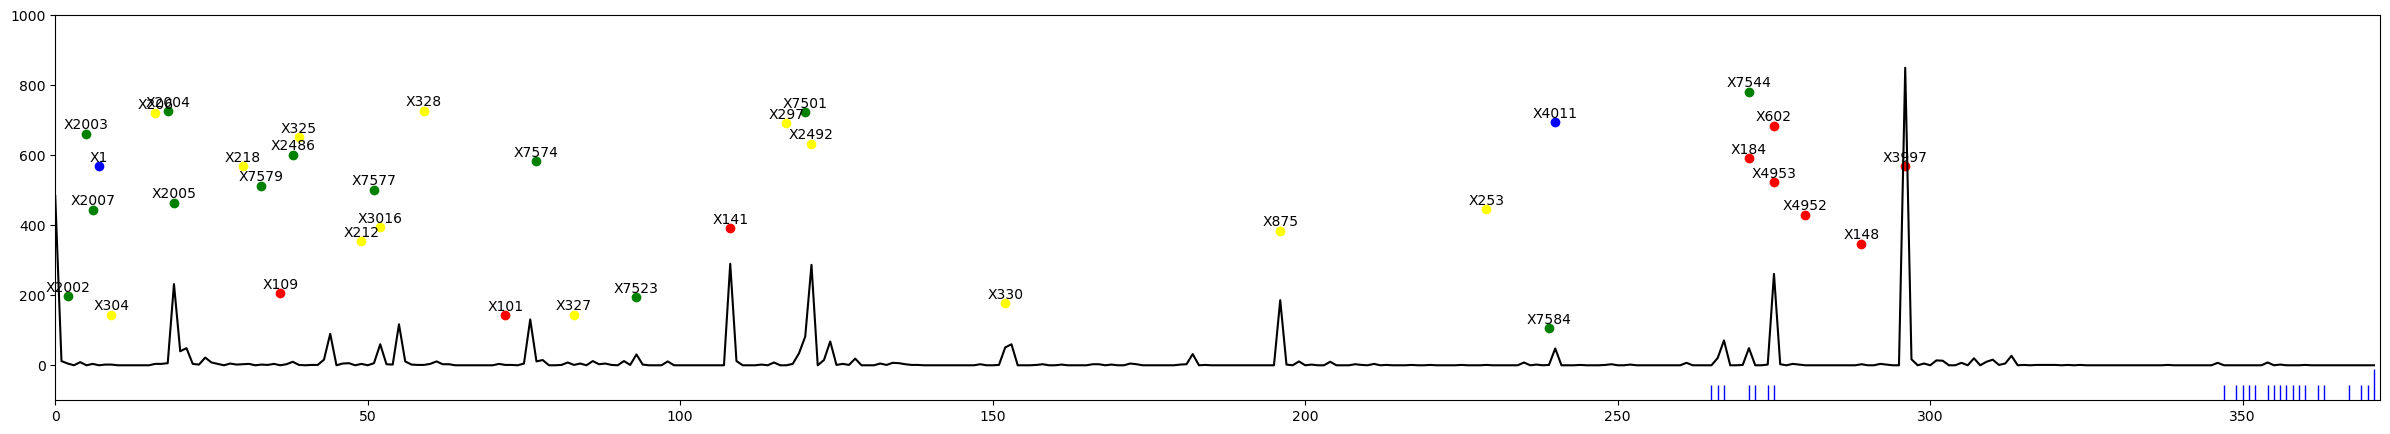

In [34]:
group12iter = {x:result.folds_folditer[x] for x in group1}

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in group12iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='black')
    plt.scatter(value, position-5, color=class2color[x2class[key]])

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, 372])
plt.ylim([-100, 1000])
# plt.savefig('folditer_group1_folds.svg', dpi=300, bbox_inches='tight')
plt.show()

# When do we see uncertainties? – singleton & multi-fold

In [35]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

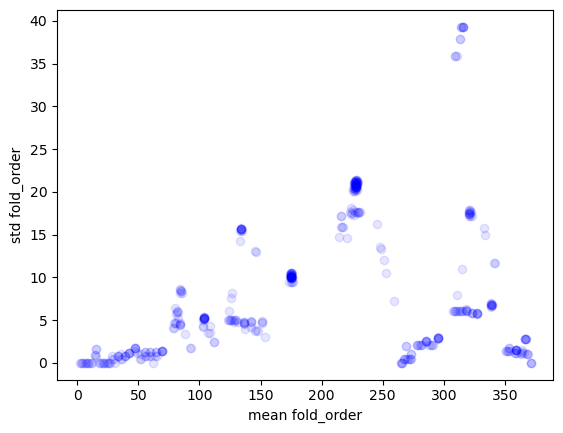

In [36]:
scatter(x2foMean, x2foStd, 'mean fold_order', 'std fold_order')

### define singleton

In [37]:
fold2fo_list = []
for run in df_folds_folditer.columns:
    fold2fo = {}
    for fold, order in df_folds_folditer[run].items():
        fold2fo[fold] = order
    fold2fo_list.append(fold2fo)

In [38]:
fo2rules_list = []
for run in df_rules_folditer.columns:
    fo2rules = {}
    for c, order in df_rules_folditer[run].items():
        if order not in fo2rules.keys():
            fo2rules[order] = [c]
        else:
            fo2rules[order].append(c)
    fo2rules_list.append(fo2rules)
    
fo2ruleNum_list = []  # NOT cummulative
for run in fo2rules_list:                   
    fo2ruleNum = {key:len(values) for key, values in run.items()}
    fo2ruleNum_list.append(fo2ruleNum)

In [39]:
fold2rulesNum_list = []  # [dicts * #runs]
for i in range(0,len(df_folds_folditer.columns)):
    fold2rulesNum = {}
    
    for fold in fold2fo_list[i].keys():
        if fold not in ['fold_independent', 'spontaneous']:
            fo = fold2fo_list[i][fold]
            fold2rulesNum[fold] = fo2ruleNum_list[i][fo]  # connect fold with # new rules
    fold2rulesNum_list.append(fold2rulesNum)
    
fold2rulesNum_all = {key:[] for key in fold2rulesNum_list[0].keys()}  # empty dict
for run in fold2rulesNum_list:
    for fold, num in run.items():
        fold2rulesNum_all[fold].append(num)

In [40]:
## annotate singletons
singleton = set()
count = 0
for x, nums in fold2rulesNum_all.items():
    if 1 in nums:  # at least one run where #new rules added == 1
#     if 1 in nums or 2 in nums or 3 in nums:  # at least one run where #new rules added <= 3
        singleton.add(x)
        if nums.count(1)/len(nums) == 1.0:  # 100% of runs
            count+=1

In [41]:
len(singleton), count

(92, 83)

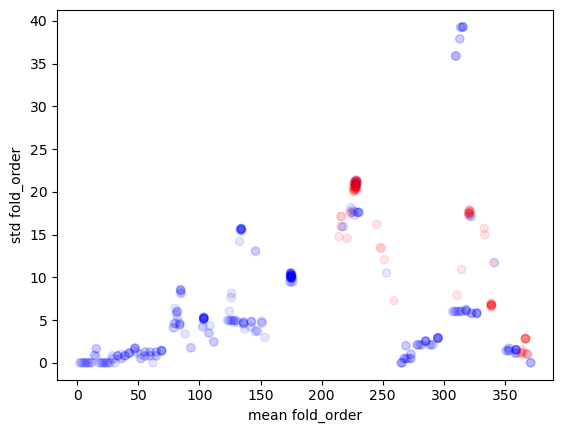

In [42]:
valid_keys, data1, data2 = todata(x2foMean, x2foStd)
colors = ['r' if key in singleton else 'b' for key in valid_keys]

plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.1, label='Data Points', zorder=2)
plt.xlabel('mean fold_order')
plt.ylabel('std fold_order')
# plt.savefig('scatter.png')
plt.show()

In [43]:
# 11 folds with x2foStd[x] > 30
# these are double-injection folds! (10 / 11 actually)

for x, nums in fold2rulesNum_all.items():
    if x2foStd[x] > 30:
        print(x, list(df_folds_folditer.loc[x]))

3321 [347, 279, 278, 348, 276, 276, 275, 276, 276, 277, 278, 347, 348, 275, 347, 347, 347, 276, 279, 348, 349, 275, 276, 275, 347, 278, 275, 275, 277, 347, 350, 277, 348, 275, 277, 347, 275, 349, 275, 276, 279, 347, 349, 347, 351, 350, 277, 277, 347, 278, 275, 276, 349, 347, 277, 347, 348, 278, 277, 347, 349, 276, 275, 275, 350, 347, 348, 275, 350, 275, 349, 276, 349, 278, 347, 276, 276, 275, 347, 348, 349, 349, 348, 347, 275, 347, 276, 279, 348, 278, 275, 351, 278, 349, 275, 347, 276, 348, 275, 276, 275, 350, 347, 276, 275, 349, 350, 275, 351, 277, 276, 347, 277, 348, 276, 347, 348, 276, 277, 275, 347, 350, 276, 350, 348, 350, 275, 348, 277, 278, 279, 278, 348, 276, 276, 276, 279, 278, 278, 275, 275, 347, 350, 347, 279, 279, 275, 347, 348, 348, 348, 275, 349, 349, 278, 350, 275, 276, 275, 276, 275, 276, 348, 275, 277, 275, 277, 347, 279, 350, 348, 277, 278, 351, 276, 350, 348, 347, 348, 276, 348, 351, 277, 351, 276, 349, 349, 277, 347, 276, 277, 278, 277, 275, 347, 275, 275, 348, 275,

In [44]:
# get all folds that can be part of multi-injection

multiples = set()
for run in fold2fo_list:
    fo2folds = {}
    for x, fo in run.items():
        if fo not in fo2folds:
            fo2folds[fo] = [x]
        else:
            fo2folds[fo].append(x)
    for fo, folds in fo2folds.items():
        if len(folds) > 1:
            multiples = multiples | set(folds)

In [45]:
len(multiples)

53

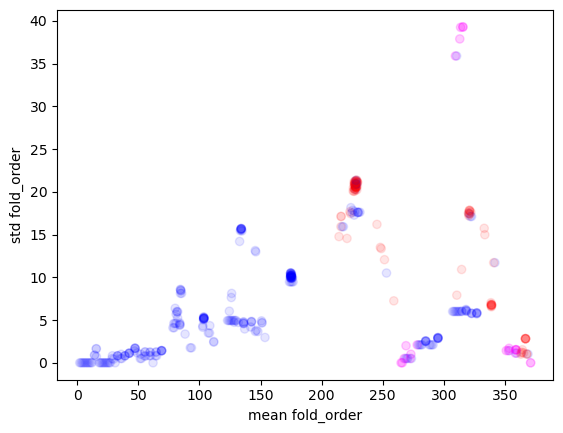

In [46]:
valid_keys, data1, data2 = todata(x2foMean, x2foStd)
colors = ['red' if key in singleton else 'magenta' if key in multiples else 'blue' for key in valid_keys]

plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.1, label='Data Points', zorder=2)
plt.xlabel('mean fold_order')
plt.ylabel('std fold_order')
# plt.savefig('scatter.png')
plt.show()

In [47]:
# # bokeh plot: color singleton red, doubles magenta
# d1 = x2foMean
# d2 = x2foStd

# output_file("singleton.html")
# p = figure(plot_width=800, plot_height=800, title="mean fold_order vs. std fold_order")

# # Add annotations
# valid_keys, data1, data2 = todata(d1, d2)

# colors = ['red' if key in singleton else 'magenta' if key in multiples else 'blue' for key in valid_keys]
# source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in valid_keys], 'color': colors}
# p.scatter('x', 'y', source=source, size=10, color='color', alpha=0.5)

# # Add hover tool
# hover = HoverTool()
# hover.tooltips = [("fold", "@label")]
# p.add_tools(hover)

# # Customize plot
# p.xaxis.axis_label = 'mean fold_order'
# p.yaxis.axis_label = 'std fold_order'
# p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
# p.xgrid.grid_line_color = None

# # Show the plot
# show(p)

# 1. usage pie charts (emerge to use, learn to use etc.)

## direct vs. indirect reactions

### get direct cofactor reactions from SI

In [48]:
# get 'direct' reactions from SI list of rns

direct_rns_SI_O2 = getDirectRns('C00007')
print(len(direct_rns_SI_O2))
direct_rns_SI_CoA = getDirectRns('C00010') | getDirectRns('Z00051')
print(len(direct_rns_SI_CoA))
direct_rns_SI_ATP = getDirectRns('C00002') | getDirectRns('C00008')
print(len(direct_rns_SI_ATP))
direct_rns_SI_SAM = getDirectRns('C00019') | getDirectRns('Z00041') # C00021 (SAH) is accessible before SAM; do not include here
print(len(direct_rns_SI_SAM))
direct_rns_SI_FAD = getDirectRns('C00016') | getDirectRns('Z00013') | getDirectRns('C01352')
print(len(direct_rns_SI_FAD))
direct_rns_SI_NAD = getDirectRns('C00003') | getDirectRns('Z00032') | getDirectRns('C00004')  # Z00032 = 'NAD/NADP'
print(len(direct_rns_SI_NAD))
direct_rns_SI_NADP = getDirectRns('C00005') | getDirectRns('Z00032') | getDirectRns('C00006')
print(len(direct_rns_SI_NADP))
direct_rns_SI_PLP = getDirectRns('C00018') | getDirectRns('Z00035')
print(len(direct_rns_SI_PLP))
direct_rns_SI_ThDP = getDirectRns('C00068') | getDirectRns('Z00047')
print(len(direct_rns_SI_ThDP))
direct_rns_SI_FMN = getDirectRns('C00061') | getDirectRns('Z00014') | getDirectRns('C01847')
print(len(direct_rns_SI_FMN))
direct_rns_SI_Cobalamin = getDirectRns('Z00009')
print(len(direct_rns_SI_Cobalamin))
direct_rns_SI_AcetylCoA = getDirectRns('C00024')
print(len(direct_rns_SI_AcetylCoA))
direct_rns_SI_IPP = getDirectRns('C00129')
print(len(direct_rns_SI_IPP))

1638
659
843
581
732
1384
1389
386
103
250
50
218
50


### get unreached reactions from ablation (direct or indirect)

In [49]:
with open('../data/rns_unreached_wo/rns_unreached_wo_O2.pkl', 'rb') as file:
    unreached_O2 = pickle.load(file)
print(len(unreached_O2))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_CoA_zCoA.pkl', 'rb') as file:
    unreached_CoA = pickle.load(file)
print(len(unreached_CoA))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_ATP_ADP.pkl', 'rb') as file:
    unreached_ATP = pickle.load(file)
print(len(unreached_ATP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_SAM_zSAM.pkl', 'rb') as file:
    unreached_SAM = pickle.load(file)
print(len(unreached_SAM))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_FAD_FADH2_zFAD.pkl', 'rb') as file:
    unreached_FAD = pickle.load(file)
print(len(unreached_FAD))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_NAD_NADH_zNAD.pkl', 'rb') as file:
    unreached_NAD = pickle.load(file)
print(len(unreached_NAD))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_NADP_NADPH_zNADP.pkl', 'rb') as file:
    unreached_NADP = pickle.load(file)
print(len(unreached_NADP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_PLP_zPLP.pkl', 'rb') as file:
    unreached_PLP = pickle.load(file)
print(len(unreached_PLP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_ThDP_zThDP.pkl', 'rb') as file:
    unreached_ThDP = pickle.load(file)
print(len(unreached_ThDP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_FMN_zFMN.pkl', 'rb') as file:
    unreached_FMN = pickle.load(file)
print(len(unreached_FMN))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_IPP.pkl', 'rb') as file:
    unreached_IPP = pickle.load(file)
print(len(unreached_IPP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_zCobalamin.pkl', 'rb') as file:
    unreached_Cobalamin = pickle.load(file)
print(len(unreached_Cobalamin))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_AcetylCoA.pkl', 'rb') as file:
    unreached_AcetylCoA = pickle.load(file)
print(len(unreached_AcetylCoA))  # from ablation

1670
3788
6788
3134
2121
6591
4259
5380
1894
3590
2304
87
2911


In [50]:
# get 'indirect' reactions:
    # 1. get reactions unreachable without cofactor (cpd ablation) from actual vanilla run
    # 2. subtract 'direct' from that
# get 'direct' reactions:
    # 1. get reactions unreachable without cofactor (cpd ablation) from actual vanilla run
    # 2. get overlap with direct_reactions from SI
    # 3. check to make sure it's the same as len(direct_rns_SI_cofactor & set(rns_scope))

indirectO2 = unreached_O2 - direct_rns_SI_O2
directO2 = unreached_O2 & direct_rns_SI_O2
print('O2: ', len(indirectO2), len(directO2), len(direct_rns_SI_O2 & set(rns_scope)))

indirectATP = unreached_ATP - direct_rns_SI_ATP 
directATP = unreached_ATP & direct_rns_SI_ATP
print('ATP:',len(indirectATP), len(directATP), len(direct_rns_SI_ATP & set(rns_scope)))

indirectCoA = unreached_CoA - direct_rns_SI_CoA
directCoA = unreached_CoA & direct_rns_SI_CoA
print('CoA:', len(indirectCoA), len(directCoA), len(direct_rns_SI_CoA & set(rns_scope)))

indirectSAM = unreached_SAM - direct_rns_SI_SAM
directSAM = unreached_SAM & direct_rns_SI_SAM
print('SAM:', len(indirectSAM), len(directSAM), len(direct_rns_SI_SAM & set(rns_scope)))

indirectFAD = unreached_FAD - direct_rns_SI_FAD
directFAD = unreached_FAD & direct_rns_SI_FAD
print('FAD:', len(indirectFAD), len(directFAD), len(direct_rns_SI_FAD & set(rns_scope)))

indirectNAD = unreached_NAD - direct_rns_SI_NAD
directNAD = unreached_NAD & direct_rns_SI_NAD
print('NAD:', len(indirectNAD), len(directNAD), len(direct_rns_SI_NAD & set(rns_scope)))

indirectNADP = unreached_NADP - direct_rns_SI_NADP
directNADP = unreached_NADP & direct_rns_SI_NADP
print('NADP:', len(indirectNADP), len(directNADP), len(direct_rns_SI_NADP & set(rns_scope)))

indirectPLP = unreached_PLP - direct_rns_SI_PLP
directPLP = unreached_PLP & direct_rns_SI_PLP
print('PLP:', len(indirectPLP), len(directPLP), len(direct_rns_SI_PLP & set(rns_scope)))

indirectThDP = unreached_ThDP - direct_rns_SI_ThDP
directThDP = unreached_ThDP & direct_rns_SI_ThDP
print('ThDP:', len(indirectThDP), len(directThDP), len(direct_rns_SI_ThDP & set(rns_scope)))

indirectFMN = unreached_FMN - direct_rns_SI_FMN
directFMN = unreached_FMN & direct_rns_SI_FMN
print('FMN:', len(indirectFMN), len(directFMN), len(direct_rns_SI_FMN & set(rns_scope)))

indirectCobalamin = unreached_Cobalamin - direct_rns_SI_Cobalamin
directCobalamin = unreached_Cobalamin & direct_rns_SI_Cobalamin
print('Cobalamin:', len(indirectCobalamin), len(directCobalamin), len(direct_rns_SI_Cobalamin & set(rns_scope)))

indirectIPP = unreached_IPP - direct_rns_SI_IPP
directIPP = unreached_IPP & direct_rns_SI_IPP
print('IPP:', len(indirectIPP), len(directIPP), len(direct_rns_SI_IPP & set(rns_scope)))

indirectAcetylCoA = unreached_AcetylCoA - direct_rns_SI_AcetylCoA
directAcetylCoA = unreached_AcetylCoA & direct_rns_SI_AcetylCoA
print('AcetylCoA:', len(indirectAcetylCoA), len(directAcetylCoA), len(direct_rns_SI_AcetylCoA & set(rns_scope)))

O2:  823 847 847
ATP: 6142 646 646
CoA: 3325 463 463
SAM: 2800 334 334
FAD: 1631 490 490
NAD: 5716 875 875
NADP: 3400 859 859
PLP: 5032 348 348
ThDP: 1798 96 96
FMN: 3411 179 179
Cobalamin: 50 37 37
IPP: 2255 49 49
AcetylCoA: 2747 164 164


#### what if we ignore Z cpds?

In [51]:
# ignore Z compounds
print('      C+Z  C')
print('-------------')

direct_rns_SI_CoA_C = getDirectRns('C00010')
print('CoA: ',len(direct_rns_SI_CoA), len(direct_rns_SI_CoA_C))
direct_rns_SI_ATP_C = getDirectRns('C00002')
print('ATP: ',len(direct_rns_SI_ATP), len(direct_rns_SI_ATP_C))
direct_rns_SI_SAM_C = getDirectRns('C00019')
print('SAM: ',len(direct_rns_SI_SAM), len(direct_rns_SI_SAM_C))
direct_rns_SI_FAD_C = getDirectRns('C00016')
print('FAD: ',len(direct_rns_SI_FAD), len(direct_rns_SI_FAD_C))
direct_rns_SI_NAD_C = getDirectRns('C00003')
print('NAD: ',len(direct_rns_SI_NAD), len(direct_rns_SI_NAD_C))
direct_rns_SI_NADP_C = getDirectRns('C00005')
print('NADP:',len(direct_rns_SI_NADP), len(direct_rns_SI_NADP_C))
direct_rns_SI_PLP_C = getDirectRns('C00018')
print('PLP: ',len(direct_rns_SI_PLP), len(direct_rns_SI_PLP_C))
direct_rns_SI_ThDP_C = getDirectRns('C00068')
print('ThDP:',len(direct_rns_SI_ThDP), len(direct_rns_SI_ThDP_C))
direct_rns_SI_FMN_C = getDirectRns('C00061')
print('FMN: ',len(direct_rns_SI_FMN), len(direct_rns_SI_FMN_C))

      C+Z  C
-------------
CoA:  659 638
ATP:  843 796
SAM:  581 564
FAD:  732 93
NAD:  1384 1078
NADP: 1389 1080
PLP:  386 15
ThDP: 103 28
FMN:  250 72


In [52]:
directFMN_C = unreached_FMN & direct_rns_SI_FMN_C
print('FMN: ', len(directFMN), len(directFMN_C), len([rn for rn in directFMN_C if rn2rev[rn]]), len([rn for rn in directFMN_C if not rn2rev[rn]]))

FMN:  179 40 25 15


In [53]:
directO2_C = unreached_O2 & direct_rns_SI_O2
print('O2: ', len(directO2), len([rn for rn in directO2 if rn2rev[rn]]))
[rn for rn in directO2 if rn2rev[rn]]

# only 1 O2 reactions is 'reversible'!

O2:  847 1


['R09503_vX']

In [54]:
print('     C+Z C rev n_rev')
print('-------------------------')

print('O2:  ', '-', len(directO2), len([rn for rn in directO2 if rn2rev[rn]]), len([rn for rn in directO2 if not rn2rev[rn]]))
directCoA_C = unreached_CoA & direct_rns_SI_CoA_C
print('CoA: ', len(directCoA), len(directCoA_C), len([rn for rn in directCoA_C if rn2rev[rn]]), len([rn for rn in directCoA_C if not rn2rev[rn]]))
directATP_C = unreached_ATP & direct_rns_SI_ATP_C
print('ATP: ', len(directATP), len(directATP_C), len([rn for rn in directATP_C if rn2rev[rn]]), len([rn for rn in directATP_C if not rn2rev[rn]]))
directSAM_C = unreached_SAM & direct_rns_SI_SAM_C
print('SAM: ', len(directSAM), len(directSAM_C), len([rn for rn in directSAM_C if rn2rev[rn]]), len([rn for rn in directSAM_C if not rn2rev[rn]]))
directFAD_C = unreached_FAD & direct_rns_SI_FAD_C
print('FAD: ', len(directFAD), len(directFAD_C), len([rn for rn in directFAD_C if rn2rev[rn]]), len([rn for rn in directFAD_C if not rn2rev[rn]]))
directNAD_C = unreached_NAD & direct_rns_SI_NAD_C
print('NAD: ', len(directNAD), len(directNAD_C), len([rn for rn in directNAD_C if rn2rev[rn]]), len([rn for rn in directNAD_C if not rn2rev[rn]]))
directNADP_C = unreached_NADP & direct_rns_SI_NADP_C
print('NADP:', len(directNADP), len(directNADP_C), len([rn for rn in directNADP_C if rn2rev[rn]]), len([rn for rn in directNADP_C if not rn2rev[rn]]))
directPLP_C = unreached_PLP & direct_rns_SI_PLP_C
print('PLP: ', len(directPLP), len(directPLP_C), len([rn for rn in directPLP_C if rn2rev[rn]]), len([rn for rn in directPLP_C if not rn2rev[rn]]))
directThDP_C = unreached_ThDP & direct_rns_SI_ThDP_C
print('ThDP: ', len(directThDP), len(directThDP_C), len([rn for rn in directThDP_C if rn2rev[rn]]), len([rn for rn in directThDP_C if not rn2rev[rn]]))
directFMN_C = unreached_FMN & direct_rns_SI_FMN_C
print('FMN: ', len(directFMN), len(directFMN_C), len([rn for rn in directFMN_C if rn2rev[rn]]), len([rn for rn in directFMN_C if not rn2rev[rn]]))

     C+Z C rev n_rev
-------------------------
O2:   - 847 1 846
CoA:  463 445 351 94
ATP:  646 606 559 47
SAM:  334 320 291 29
FAD:  490 53 45 8
NAD:  875 661 538 123
NADP: 859 644 472 172
PLP:  348 15 8 7
ThDP:  96 28 20 8
FMN:  179 40 25 15


### upset plot to visualize their intersections

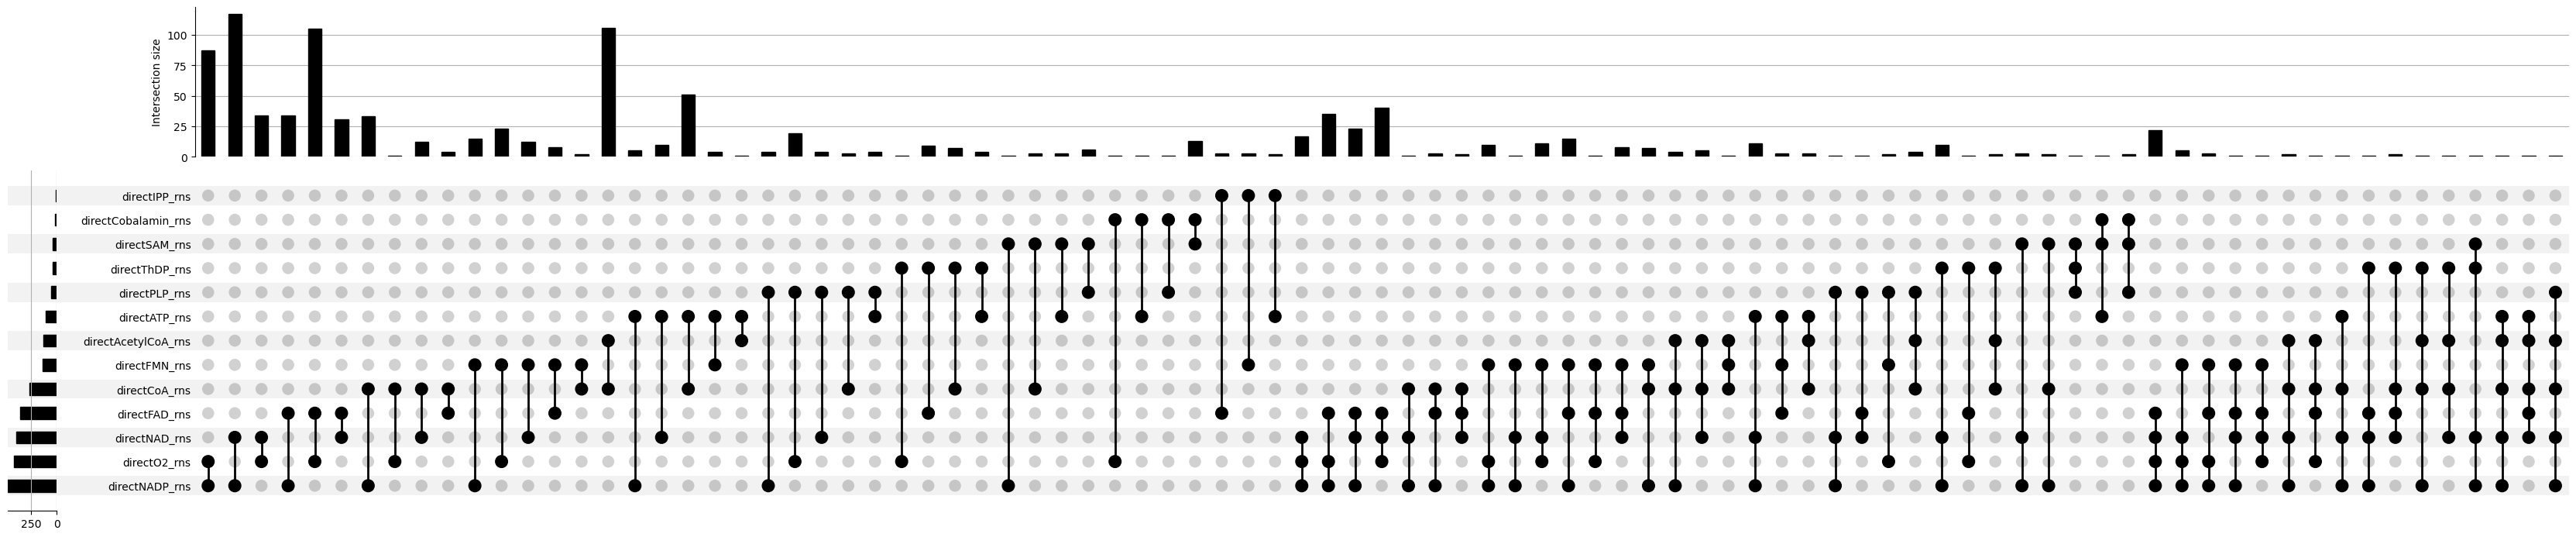

In [55]:
from upsetplot import UpSet

import warnings
# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

# Create a dictionary with all sets
sets = {
    'directO2_rns': directO2,
    'directATP_rns': directATP,
    'directCoA_rns': directCoA,
    'directSAM_rns': directSAM,
    'directFAD_rns': directFAD,
    'directNAD_rns': directNAD,
    'directNADP_rns': directNADP,
    'directPLP_rns': directPLP,
    'directThDP_rns': directThDP,
    'directFMN_rns': directFMN,
    'directCobalamin_rns': directCobalamin,
    'directIPP_rns': directIPP,
    'directAcetylCoA_rns': directAcetylCoA
}

# Generate DataFrame suitable for UpSet plot
all_elements = set.union(*sets.values())
data = {elem: [elem in sets[set_name] for set_name in sets] for elem in all_elements}

# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=sets.keys())

# Create a MultiIndex from boolean DataFrame
df.index = pd.MultiIndex.from_frame(df.astype(bool).reset_index(drop=True))

# Filter out self-intersections
df = df[df.sum(axis=1) > 1]

# Aggregate the data by the MultiIndex to get counts
df_counts = df.groupby(level=list(df.index.names)).size()

# Create the UpSet plot
upset = UpSet(df_counts)
upset.plot()
plt.show()

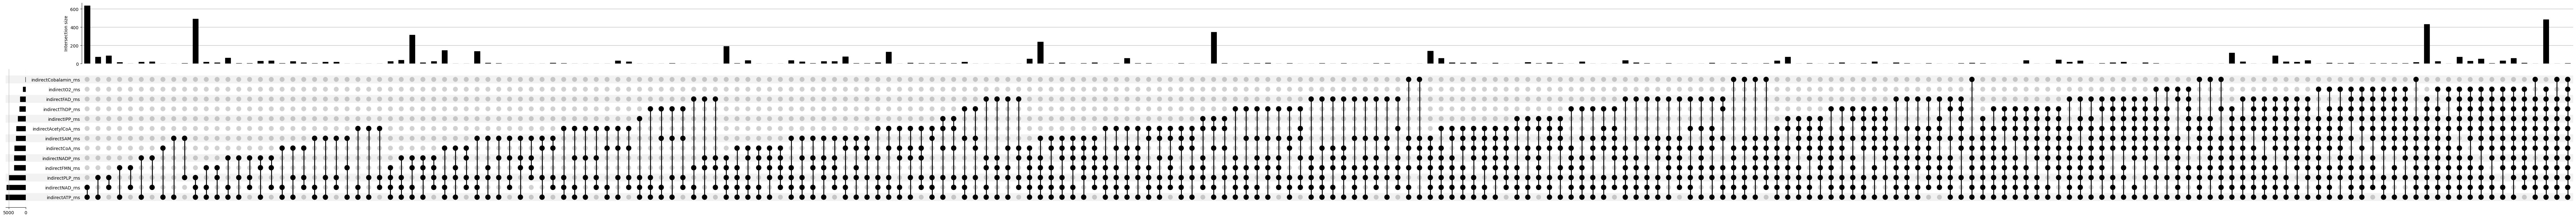

In [56]:
# Create a dictionary with all sets
sets = {
    'indirectO2_rns': indirectO2,
    'indirectATP_rns': indirectATP,
    'indirectCoA_rns': indirectCoA,
    'indirectSAM_rns': indirectSAM,
    'indirectFAD_rns': indirectFAD,
    'indirectNAD_rns': indirectNAD,
    'indirectNADP_rns': indirectNADP,
    'indirectPLP_rns': indirectPLP,
    'indirectThDP_rns': indirectThDP,
    'indirectFMN_rns': indirectFMN,
    'indirectCobalamin_rns': indirectCobalamin,
    'indirectIPP_rns': indirectIPP,
    'indirectAcetylCoA_rns': indirectAcetylCoA
}

# Generate DataFrame suitable for UpSet plot
all_elements = set.union(*sets.values())
data = {elem: [elem in sets[set_name] for set_name in sets] for elem in all_elements}

# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=sets.keys())

# Create a MultiIndex from boolean DataFrame
df.index = pd.MultiIndex.from_frame(df.astype(bool).reset_index(drop=True))

# Filter out self-intersections
df = df[df.sum(axis=1) > 1]

# Aggregate the data by the MultiIndex to get counts
df_counts = df.groupby(level=list(df.index.names)).size()

# Create the UpSet plot
upset = UpSet(df_counts)
upset.plot()
plt.show()

### calculate fraction of reactions that are direct cofactor-utilizing 

In [57]:
# make x2rn with the same scope as our simulations

x2rn_scope = {}
for x, rns in x2rn.items():
    scope_rns = []
    for rn in rns:
        if rn in rns_scope:  # check if rn appears in our simulations
            scope_rns.append(rn)
    x2rn_scope[x] = scope_rns

In [58]:
x2rnNum = {x:len(rns) for x, rns in x2rn.items()}
x2rnNum_scope = {x:len(rns) for x, rns in x2rn_scope.items()}

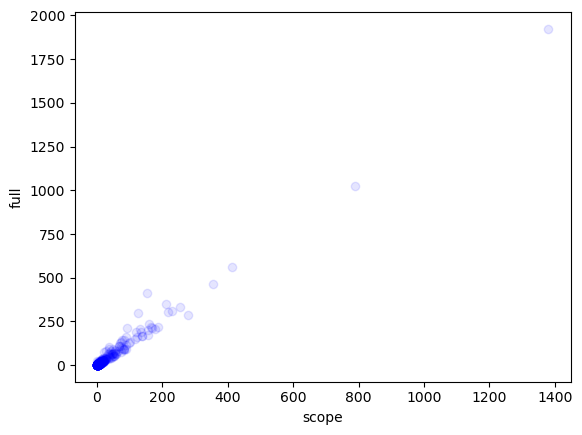

In [59]:
scatter(x2rnNum_scope, x2rnNum, 'scope', 'full')

In [60]:
def makeCofactorDicts(direct_rns, indirect_rns):
    # make categorical dict
    x2rn_cofactor = {}
    for x, rns in x2rn_scope.items():
        fracdict = {'direct':[], 'indirect':[], 'total':[]}
        for rn in rns:
            if rn in direct_rns:
                fracdict['direct'].append(rn)
            if rn in indirect_rns:
                fracdict['indirect'].append(rn)
            fracdict['total'].append(rn)
        x2rn_cofactor[x] = fracdict
    
    # make fraction dict
    x2rnFrac_cofactor = {}
    for x, d in x2rn_cofactor.items():
        dir_total = len(d['direct']) / len(d['total'])
        ind_total = len(d['indirect']) / len(d['total'])
        dir_ind_total = len((set(d['direct']) | set(d['indirect']))) / len(d['total'])
        x2rnFrac_cofactor[x] = [dir_total, ind_total, dir_ind_total]
    
    return x2rn_cofactor, x2rnFrac_cofactor

In [61]:
x2rn_O2, x2rnFrac_O2 = makeCofactorDicts(directO2, indirectO2)
x2rn_ATP, x2rnFrac_ATP = makeCofactorDicts(directATP, indirectATP)
x2rn_CoA, x2rnFrac_CoA = makeCofactorDicts(directCoA, indirectCoA)
x2rn_SAM, x2rnFrac_SAM = makeCofactorDicts(directSAM, indirectSAM)
x2rn_FAD, x2rnFrac_FAD = makeCofactorDicts(directFAD, indirectFAD)

x2rn_NAD, x2rnFrac_NAD = makeCofactorDicts(directNAD, indirectNAD)
x2rn_NADP, x2rnFrac_NADP = makeCofactorDicts(directNADP, indirectNADP)
x2rn_PLP, x2rnFrac_PLP = makeCofactorDicts(directPLP, indirectPLP)
x2rn_ThDP, x2rnFrac_ThDP = makeCofactorDicts(directThDP, indirectThDP)

x2rn_FMN, x2rnFrac_FMN = makeCofactorDicts(directFMN, indirectFMN)
x2rn_IPP, x2rnFrac_IPP = makeCofactorDicts(directIPP, indirectIPP)
x2rn_Cobalamin, x2rnFrac_Cobalamin = makeCofactorDicts(directCobalamin, indirectCobalamin)
x2rn_AcetylCoA, x2rnFrac_AcetylCoA = makeCofactorDicts(directAcetylCoA, indirectAcetylCoA)

### plot fractions against mean fold order (x2foAve)

In [62]:
x2rnFrac_O2_0 = {x:values[0] for x, values in x2rnFrac_O2.items()}
x2rnFrac_O2_1 = {x:values[1] for x, values in x2rnFrac_O2.items()}
x2rnFrac_O2_2 = {x:values[2] for x, values in x2rnFrac_O2.items()}

x2rnFrac_ATP_0 = {x:values[0] for x, values in x2rnFrac_ATP.items()}
x2rnFrac_ATP_1 = {x:values[1] for x, values in x2rnFrac_ATP.items()}
x2rnFrac_ATP_2 = {x:values[2] for x, values in x2rnFrac_ATP.items()}

x2rnFrac_CoA_0 = {x:values[0] for x, values in x2rnFrac_CoA.items()}
x2rnFrac_CoA_1 = {x:values[1] for x, values in x2rnFrac_CoA.items()}
x2rnFrac_CoA_2 = {x:values[2] for x, values in x2rnFrac_CoA.items()}

x2rnFrac_SAM_0 = {x:values[0] for x, values in x2rnFrac_SAM.items()}
x2rnFrac_SAM_1 = {x:values[1] for x, values in x2rnFrac_SAM.items()}
x2rnFrac_SAM_2 = {x:values[2] for x, values in x2rnFrac_SAM.items()}

x2rnFrac_FAD_0 = {x:values[0] for x, values in x2rnFrac_FAD.items()}
x2rnFrac_FAD_1 = {x:values[1] for x, values in x2rnFrac_FAD.items()}
x2rnFrac_FAD_2 = {x:values[2] for x, values in x2rnFrac_FAD.items()}

x2rnFrac_NAD_0 = {x:values[0] for x, values in x2rnFrac_NAD.items()}
x2rnFrac_NAD_1 = {x:values[1] for x, values in x2rnFrac_NAD.items()}
x2rnFrac_NAD_2 = {x:values[2] for x, values in x2rnFrac_NAD.items()}

x2rnFrac_NADP_0 = {x:values[0] for x, values in x2rnFrac_NADP.items()}
x2rnFrac_NADP_1 = {x:values[1] for x, values in x2rnFrac_NADP.items()}
x2rnFrac_NADP_2 = {x:values[2] for x, values in x2rnFrac_NADP.items()}

x2rnFrac_PLP_0 = {x:values[0] for x, values in x2rnFrac_PLP.items()}
x2rnFrac_PLP_1 = {x:values[1] for x, values in x2rnFrac_PLP.items()}
x2rnFrac_PLP_2 = {x:values[2] for x, values in x2rnFrac_PLP.items()}

x2rnFrac_ThDP_0 = {x:values[0] for x, values in x2rnFrac_ThDP.items()}
x2rnFrac_ThDP_1 = {x:values[1] for x, values in x2rnFrac_ThDP.items()}
x2rnFrac_ThDP_2 = {x:values[2] for x, values in x2rnFrac_ThDP.items()}

x2rnFrac_FMN_0 = {x:values[0] for x, values in x2rnFrac_FMN.items()}
x2rnFrac_FMN_1 = {x:values[1] for x, values in x2rnFrac_FMN.items()}
x2rnFrac_FMN_2 = {x:values[2] for x, values in x2rnFrac_FMN.items()}

x2rnFrac_IPP_0 = {x:values[0] for x, values in x2rnFrac_IPP.items()}
x2rnFrac_IPP_1 = {x:values[1] for x, values in x2rnFrac_IPP.items()}
x2rnFrac_IPP_2 = {x:values[2] for x, values in x2rnFrac_IPP.items()}

x2rnFrac_Cobalamin_0 = {x:values[0] for x, values in x2rnFrac_Cobalamin.items()}
x2rnFrac_Cobalamin_1 = {x:values[1] for x, values in x2rnFrac_Cobalamin.items()}
x2rnFrac_Cobalamin_2 = {x:values[2] for x, values in x2rnFrac_Cobalamin.items()}

x2rnFrac_AcetylCoA_0 = {x:values[0] for x, values in x2rnFrac_AcetylCoA.items()}
x2rnFrac_AcetylCoA_1 = {x:values[1] for x, values in x2rnFrac_AcetylCoA.items()}
x2rnFrac_AcetylCoA_2 = {x:values[2] for x, values in x2rnFrac_AcetylCoA.items()}

02 (0.26497714053965393, '8.685304e-08')


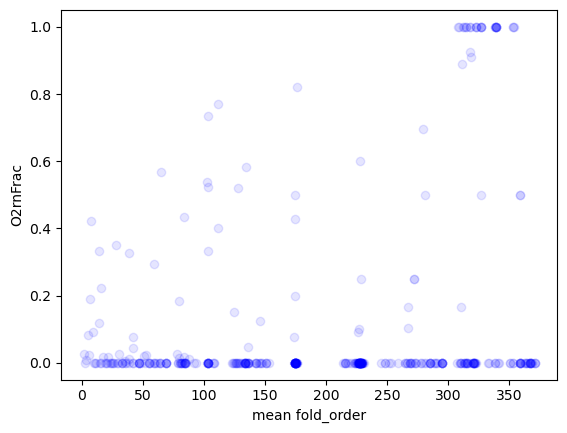

ATP (-0.014093526063696425, '7.797960e-01')


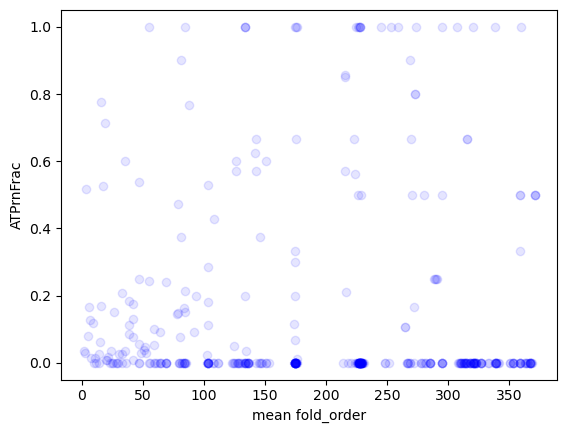

CoA (0.007932391516128635, '8.749642e-01')


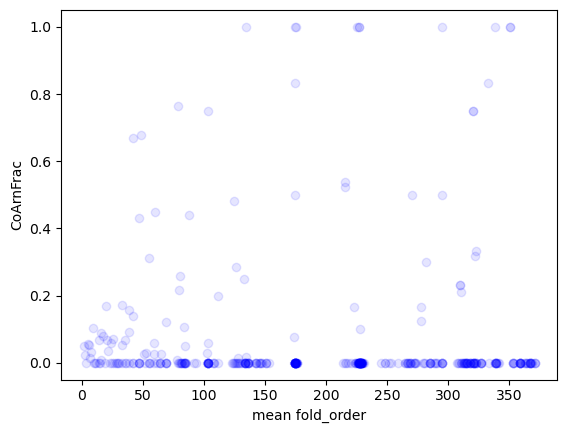

SAM (0.0732854527648615, '1.454728e-01')


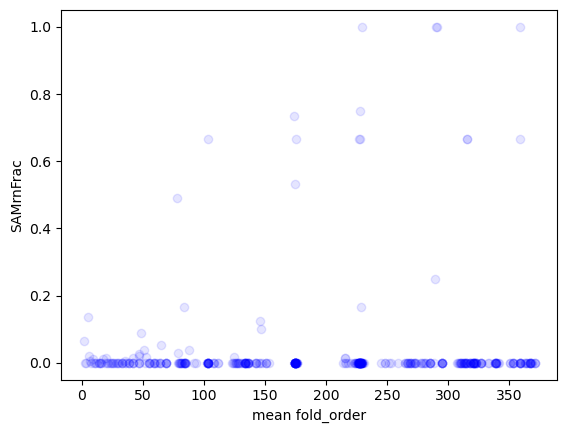

FAD (0.07302791314496607, '1.468967e-01')


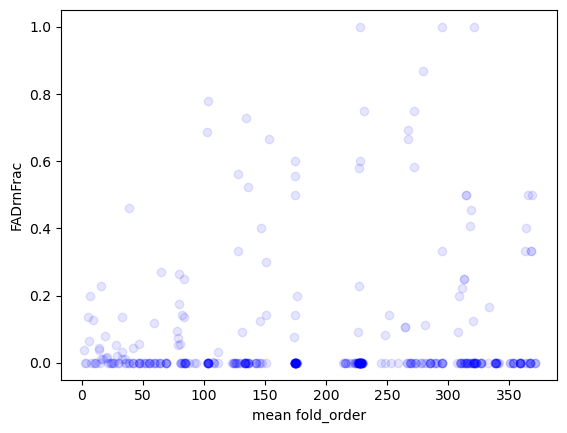

In [63]:
print('02', pearson(x2foMean, x2rnFrac_O2_0))
scatter(x2foMean, x2rnFrac_O2_0, x_axis='mean fold_order', y_axis='O2rnFrac')

print('ATP', pearson(x2foMean, x2rnFrac_ATP_0))
scatter(x2foMean, x2rnFrac_ATP_0, x_axis='mean fold_order', y_axis='ATPrnFrac')

print('CoA', pearson(x2foMean, x2rnFrac_CoA_0))
scatter(x2foMean, x2rnFrac_CoA_0, x_axis='mean fold_order', y_axis='CoArnFrac')

print('SAM', pearson(x2foMean, x2rnFrac_SAM_0))
scatter(x2foMean, x2rnFrac_SAM_0, x_axis='mean fold_order', y_axis='SAMrnFrac')

print('FAD', pearson(x2foMean, x2rnFrac_FAD_0))
scatter(x2foMean, x2rnFrac_FAD_0, x_axis='mean fold_order', y_axis='FADrnFrac')

02 (0.2122425851822635, '2.054898e-05')


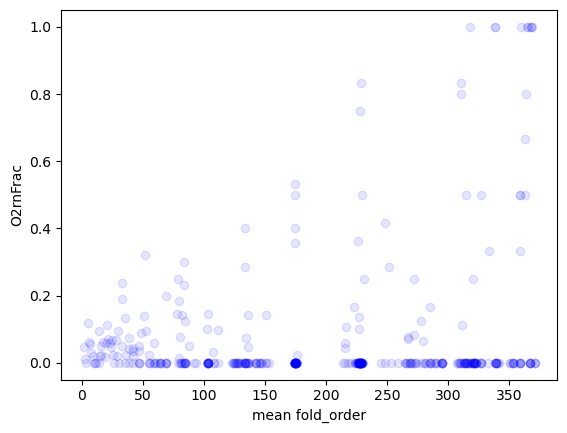

ATP (0.10801880049231048, '3.163095e-02')


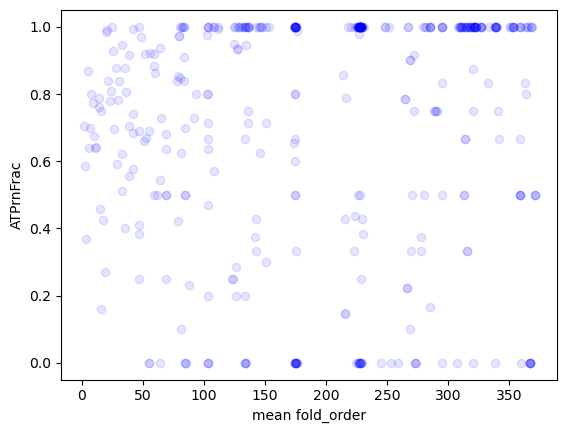

CoA (0.30705393319656105, '4.308702e-10')


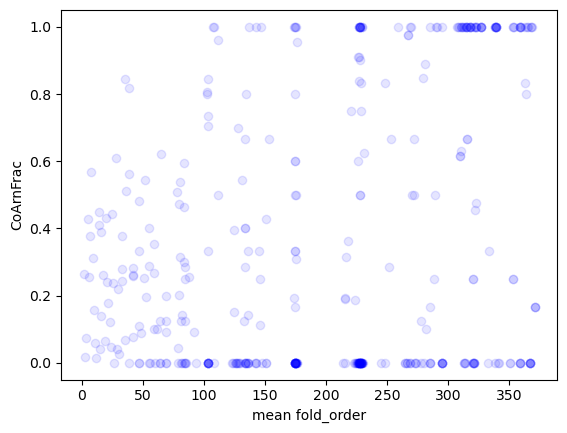

SAM (0.3941097215930046, '3.636146e-16')


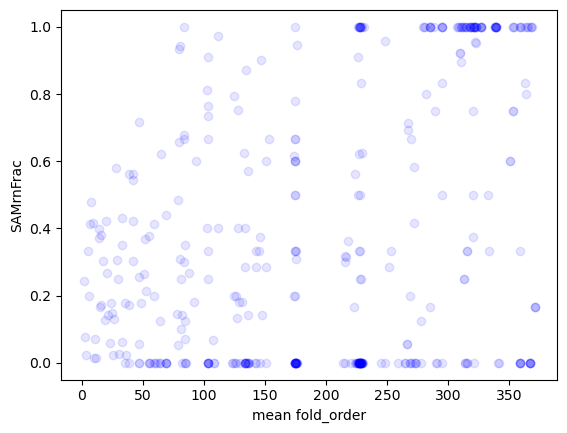

FAD (0.34062261384725023, '3.254241e-12')


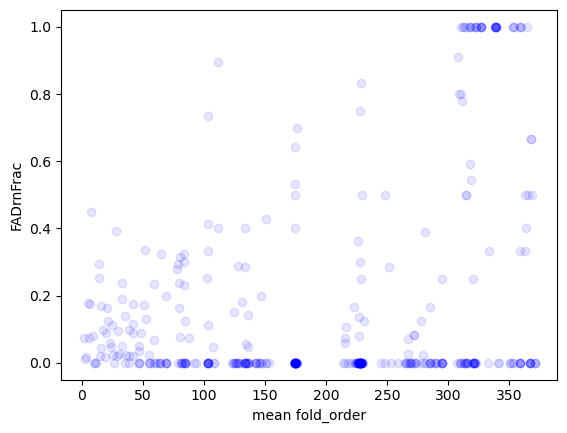

In [64]:
print('02', pearson(x2foMean, x2rnFrac_O2_1))
scatter(x2foMean, x2rnFrac_O2_1, x_axis='mean fold_order', y_axis='O2rnFrac')

print('ATP', pearson(x2foMean, x2rnFrac_ATP_1))
scatter(x2foMean, x2rnFrac_ATP_1, x_axis='mean fold_order', y_axis='ATPrnFrac')

print('CoA', pearson(x2foMean, x2rnFrac_CoA_1))
scatter(x2foMean, x2rnFrac_CoA_1, x_axis='mean fold_order', y_axis='CoArnFrac')

print('SAM', pearson(x2foMean, x2rnFrac_SAM_1))
scatter(x2foMean, x2rnFrac_SAM_1, x_axis='mean fold_order', y_axis='SAMrnFrac')

print('FAD', pearson(x2foMean, x2rnFrac_FAD_1))
scatter(x2foMean, x2rnFrac_FAD_1, x_axis='mean fold_order', y_axis='FADrnFrac')

02 (0.34898640017103216, '8.755138e-13')


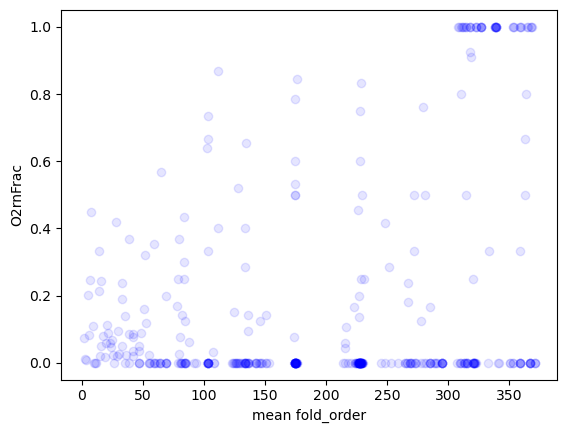

ATP (0.12272505988480566, '1.453663e-02')


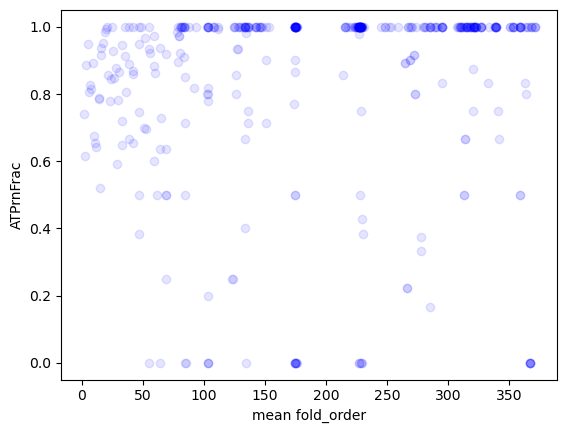

CoA (0.30085885083462727, '9.948978e-10')


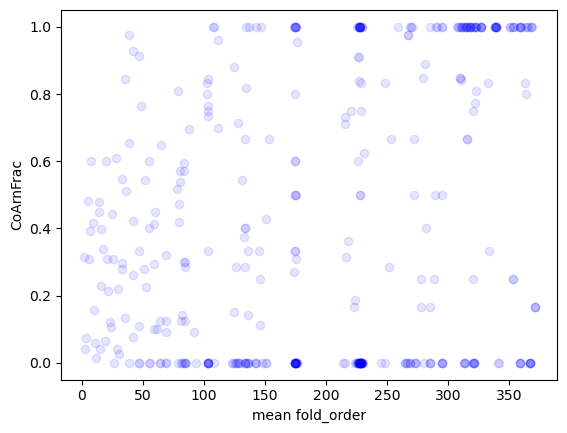

SAM (0.4078954247952322, '2.623566e-17')


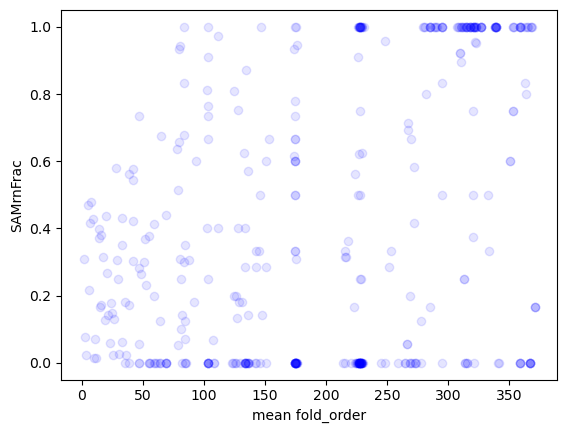

FAD (0.32604118864366727, '2.926638e-11')


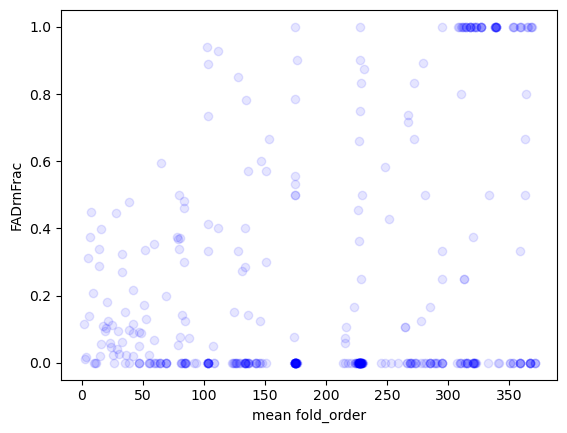

In [65]:
print('02', pearson(x2foMean, x2rnFrac_O2_2))
scatter(x2foMean, x2rnFrac_O2_2, x_axis='mean fold_order', y_axis='O2rnFrac')

print('ATP', pearson(x2foMean, x2rnFrac_ATP_2))
scatter(x2foMean, x2rnFrac_ATP_2, x_axis='mean fold_order', y_axis='ATPrnFrac')

print('CoA', pearson(x2foMean, x2rnFrac_CoA_2))
scatter(x2foMean, x2rnFrac_CoA_2, x_axis='mean fold_order', y_axis='CoArnFrac')

print('SAM', pearson(x2foMean, x2rnFrac_SAM_2))
scatter(x2foMean, x2rnFrac_SAM_2, x_axis='mean fold_order', y_axis='SAMrnFrac')

print('FAD', pearson(x2foMean, x2rnFrac_FAD_2))
scatter(x2foMean, x2rnFrac_FAD_2, x_axis='mean fold_order', y_axis='FADrnFrac')

### look for folds that are strongly dependent on each cofactor

In [66]:
def getDependentFolds(x2rnFrac_Cofactor):
    x_all_direct_Cofactor = set()
    x_all_indirect_Cofactor = set()
    x_all_Cofactor = set()

    for x, fracs in x2rnFrac_Cofactor.items():
        if fracs[0] == 1:
            x_all_direct_Cofactor.add(x)    
        if fracs[1] == 1:
            x_all_indirect_Cofactor.add(x)
        if fracs[2] == 1:
            x_all_Cofactor.add(x)
            
    return x_all_direct_Cofactor, x_all_indirect_Cofactor, x_all_Cofactor

In [67]:
print('     D  I  D+I')
print('---------------')
x_all_direct_ATP, x_all_indirect_ATP, x_all_ATP = getDependentFolds(x2rnFrac_ATP)
print('ATP:', len(x_all_direct_ATP), len(x_all_indirect_ATP), len(x_all_ATP))

x_all_direct_SAM, x_all_indirect_SAM, x_all_SAM = getDependentFolds(x2rnFrac_SAM)
print('SAM:',len(x_all_direct_SAM), len(x_all_indirect_SAM), len(x_all_SAM))

x_all_direct_CoA, x_all_indirect_CoA, x_all_CoA = getDependentFolds(x2rnFrac_CoA)
print('CoA:', len(x_all_direct_CoA), len(x_all_indirect_CoA), len(x_all_CoA))

x_all_direct_FAD, x_all_indirect_FAD, x_all_FAD = getDependentFolds(x2rnFrac_FAD)
print('FAD:', len(x_all_direct_FAD), len(x_all_indirect_FAD), len(x_all_FAD))

x_all_direct_O2, x_all_indirect_O2, x_all_O2 = getDependentFolds(x2rnFrac_O2)
print('O2: ', len(x_all_direct_O2), len(x_all_indirect_O2), len(x_all_O2))

     D  I  D+I
---------------
ATP: 23 171 242
SAM: 4 78 92
CoA: 10 78 92
FAD: 3 33 48
O2:  26 9 40


In [68]:
# all_direct folds do not overlap much

print(x_all_direct_ATP)
print(x_all_direct_SAM)
print(x_all_direct_CoA)
print(x_all_direct_FAD)
print(x_all_direct_O2)

{'3994', '4076', '7604', '3264', '1143', '253', '3086', '4004', '5103', '876', '3076', '6075', '7536', '199', '3997', '196', '1144', '377', '4114', '7589', '7500', '4279', '7562'}
{'69', '7540', '3993', '3005'}
{'6113', '6051', '5067', '3960', '4971', '4223', '3001', '1114', '147', '172'}
{'842', '3892', '313'}
{'192', '603', '4159', '3752', '3115', '6174', '3978', '158', '3207', '4229', '241', '146', '262', '881', '3777', '7', '4983', '257', '3249', '228', '6', '4110', '640', '4160', '557', '2012'}


In [69]:
# significant overlap for x_all_cofactor sets

In [70]:
x_all_CoA == x_all_FAD

False

In [71]:
x_all_CoA - x_all_SAM

{'1114',
 '1119',
 '1144',
 '141',
 '147',
 '172',
 '197',
 '2008',
 '2496',
 '268',
 '3001',
 '319',
 '3599',
 '3688',
 '3754',
 '3794',
 '4194',
 '4223',
 '4295',
 '4971',
 '5038',
 '5067',
 '6113',
 '7534',
 '7550',
 '7595'}

In [72]:
x_all_CoA - x_all_O2

{'1114',
 '1119',
 '1144',
 '136',
 '139',
 '141',
 '147',
 '148',
 '154',
 '172',
 '197',
 '2008',
 '2496',
 '268',
 '296',
 '3001',
 '3005',
 '319',
 '324',
 '3269',
 '3599',
 '3687',
 '3688',
 '3754',
 '3794',
 '3993',
 '3997',
 '4024',
 '4029',
 '4049',
 '4194',
 '4223',
 '4237',
 '4262',
 '4294',
 '4295',
 '4971',
 '5038',
 '5039',
 '5067',
 '582',
 '6051',
 '608',
 '6113',
 '66',
 '69',
 '7534',
 '7550',
 '7578',
 '7595',
 '872',
 '9'}

### get 'direct' folds that have cofactors in equation

In [73]:
direct_folds_O2 = [x for x,v in x2rnFrac_O2.items() if v[0] > 0]
print(len(direct_folds_O2))
direct_folds_ATP = [x for x,v in x2rnFrac_ATP.items() if v[0] > 0]
print(len(direct_folds_ATP))
direct_folds_CoA = [x for x,v in x2rnFrac_CoA.items() if v[0] > 0]
print(len(direct_folds_CoA))
direct_folds_SAM = [x for x,v in x2rnFrac_SAM.items() if v[0] > 0]
print(len(direct_folds_SAM))
direct_folds_FAD = [x for x,v in x2rnFrac_FAD.items() if v[0] > 0]
print(len(direct_folds_FAD))
direct_folds_NAD = [x for x,v in x2rnFrac_NAD.items() if v[0] > 0]
print(len(direct_folds_NAD))
direct_folds_NADP = [x for x,v in x2rnFrac_NADP.items() if v[0] > 0]
print(len(direct_folds_NADP))
direct_folds_PLP = [x for x,v in x2rnFrac_PLP.items() if v[0] > 0]
print(len(direct_folds_PLP))
direct_folds_ThDP = [x for x,v in x2rnFrac_ThDP.items() if v[0] > 0]
print(len(direct_folds_ThDP))
direct_folds_IPP = [x for x,v in x2rnFrac_IPP.items() if v[0] > 0]
print(len(direct_folds_IPP))
direct_folds_FMN = [x for x,v in x2rnFrac_FMN.items() if v[0] > 0]
print(len(direct_folds_FMN))
direct_folds_Cobalamin = [x for x,v in x2rnFrac_Cobalamin.items() if v[0] > 0]
print(len(direct_folds_Cobalamin))
direct_folds_AcetylCoA = [x for x,v in x2rnFrac_AcetylCoA.items() if v[0] > 0]
print(len(direct_folds_AcetylCoA))

88
132
79
40
89
127
120
41
22
8
75
16
63


# 2. ETU (Emerge to Use) folds

In [74]:
# preATP

df_folds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_cumiter_preATP.csv', index_col=0)
df_cpds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_cumiter_preATP.csv', index_col=0)
df_rns_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_cumiter_preATP.csv', index_col=0)
df_rules_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_cumiter_preATP.csv', index_col=0)

In [75]:
# NONE

# df_folds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_cumiter_NONE.csv', index_col=0)
# df_cpds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_cumiter_NONE.csv', index_col=0)
# df_rns_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_cumiter_NONE.csv', index_col=0)
# df_rules_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rules_cumiter_NONE.csv', index_col=0)

In [76]:
# this takes time
# collect cumiter2rules for all 1000 runs

cumiter2rules_all_runs = {}
for run in df_rules_cumiter:
    cumiter2rules = {}
    for rule, i in df_rules_cumiter[run].items():
        if i not in cumiter2rules:
            cumiter2rules[i] = [eval(rule)]  # convert string into tuple with 'eval'
        else:
            cumiter2rules[i].append(eval(rule))
    cumiter2rules_all_runs[run] = cumiter2rules

### helper function to differentiate cofactor 'using' and 'producing' reactions

In [77]:
# helper function to return reactions that 'use' or 'produce' given cofactor when discovered
# change the condition in 'else' to either:
    # (1) compare cumiters of cpds to decide direction of rev reactions
    # (2) return reac_iters and prod_iters to compare with fold-cumiter in main function

def getUsingProducingRns(run, cofactor, direct_cofactor_rns):
    cofactor_using = []
    both = {}
    cofactor_producing = []

    if cofactor.startswith('Z'):
        print('this function cannot be used with Z compounds, since they are not consumed!')
        return None
    
    for rn in direct_cofactor_rns:

        if rn2direction[rn] == 'forward':
            if cofactor in rn2prod[rn]: # forward AND cpd is in prod
                cofactor_producing.append(rn) 
            else:
                cofactor_using.append(rn)
        elif rn2direction[rn] == 'reverse':
            if cofactor in rn2reac[rn]: # reverse AND cpd is in reac
                cofactor_producing.append(rn) 
            else:
                cofactor_using.append(rn)
        else:  # reversible 
            reac_iters = [df_cpds_cumiter[run][c] for c in rn2reac[rn]]
            prod_iters = [df_cpds_cumiter[run][c] for c in rn2prod[rn]]
            
            # # (1) compare cumiter of cpds
            # if max(reac_iters) > max(prod_iters):  # reverse
            #     if cofactor in rn2prod[rn]:
            #         cofactor_using.append(rn)
            #     else:
            #         cofactor_producing.append(rn)
            # elif max(reac_iters) < max(prod_iters):  # forward
            #     if cofactor in rn2reac[rn]:
            #         cofactor_using.append(rn)
            #     else:
            #         cofactor_producing.append(rn)
            # else:  # same max cumiter
            #     both.append(rn)

            # (2) instead, return max cumiters of reac and prod to be compared to 'fold cumiter' later
            both[rn] = (max(reac_iters), max(prod_iters))
            
    return cofactor_using, both, cofactor_producing

# example
run = '87452'
cofactor = 'C00007'
direct_cofactor_rns = directO2
using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rns)
print(len(directO2), len(using), len(both), len(producing))

847 826 1 20


In [78]:
# check all of them
cid2directRns = {'C00007': directO2, 'C00002': directATP, 'C00010': directCoA, 'C00019': directSAM, 'C00016': directFAD, 'C00003': directNAD, 'C00005': directNADP, 'C00018': directPLP, 'C00068': directThDP, 'C00061': directFMN, 'C00129': directIPP, 'C00024': directAcetylCoA}
run = '87452'
for cid, direct_cofactor_rns in cid2directRns.items():
    using, both, producing = getUsingProducingRns(run, cid, direct_cofactor_rns)
    print(cid, len(direct_cofactor_rns), len(using), len(both), len(producing))

C00007 847 826 1 20
C00002 646 43 595 8
C00010 463 18 368 77
C00019 334 32 302 0
C00016 490 298 188 4
C00003 875 136 648 91
C00005 859 258 582 19
C00018 348 71 272 5
C00068 96 20 69 7
C00061 179 75 94 10
C00129 49 34 14 1
C00024 164 14 147 3


### getETC_UC: function to collect folds that 'emerge to use' a given cpd

In [79]:
# for C+Z (e.g. cofactors)
def getETU_UC(direct_cofactor_rn_set, direct_cofactor_fold_set=None):
    
    recruited_folds_allruns = []
    for run, cumiter2rules in cumiter2rules_all_runs.items():
        
        # collect a list of rnRules discovered at the same time as fold injection
        x2first_rules = {} 
        for x, i in df_folds_cumiter[run].items():
            if direct_cofactor_fold_set == None:  # no fold_set given
                if x != 'fold_independent':
                    x2first_rules[x] = cumiter2rules[i]
            else:
                if x in direct_cofactor_fold_set:  # only look at folds we already know have cofactor-using reactions
                    x2first_rules[x] = cumiter2rules[i]
                
        # LOOSE: ETU if ANY reaction uses the cofactor
        # recruited_folds = set()
        # for x, rules in x2first_rules.items():
        #     for rule in rules:
        #         if rule[0] in direct_cofactor_rn_set:  # direct cofactor rns 
        #             recruited_folds.add(x)
        
        # STRICT: ETU if ALL reactions use the cofactor
        recruited_folds = set()
        for x, rules in x2first_rules.items():
            count = 0
            # count num of cofactor reactions
            for rule in rules:
                if rule[0] in direct_cofactor_rn_set:  # direct cofactor rns 
                    count += 1
            if count == len(rules):  # if all reactions use the cofactor
                recruited_folds.add(x)        

        recruited_folds_allruns.append(recruited_folds)

    # tally of all folds
    l = []  
    for run in recruited_folds_allruns:
        for x in run:
            l.append(x)
    
    # divide based on threshold
    emerged_to_use = set()
    unclassified = set()
    for x in set(l):
#         print(l.count(x)/len(df_rules_cumiter.columns))
        if l.count(x)/len(df_rules_cumiter.columns) >= 0.75:  # change threshold here
            emerged_to_use.add(x)
        else:
            unclassified.add(x)

    # return the set of folds 'recruited for' the cofactor
    return emerged_to_use, unclassified

In [80]:
# for C compounds (e.g. O2)

def getETU_UC_C(cofactor, direct_cofactor_rn_set, direct_cofactor_fold_set=None):
    recruited_folds_allruns = []
    # just use one run to get using_producing reactions (2a)
    run = '87452'
    using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rn_set)
    
    for run, cumiter2rules in cumiter2rules_all_runs.items():
        # uncomment if using (2b) option below
        # it will look at cumiters of cpds IN EACH RUN to decide the direction of reversible reactions
        # using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rn_set)
        
        # collect a list of rnRules discovered at the same time as fold injection
        x2first_rules = {} 
        for x, i in df_folds_cumiter[run].items():
            if direct_cofactor_fold_set == None:  # no fold_set given
                if x != 'fold_independent':
                    x2first_rules[x] = cumiter2rules[i]
            else:
                if x in direct_cofactor_fold_set:  # only look at folds we already know have cofactor-using reactions
                    x2first_rules[x] = cumiter2rules[i]
                
        # go through the reactions and determine their direction => collect cases where the fold 'used' the cofactor
        # STRICT: ETU if ALL reactions use the cofactor
        recruited_folds = set()
        for x, rules in x2first_rules.items():
            count = 0
            for rule in rules:

                # differentiate usage vs. production (reactant vs. product)
                if rule[0] in using:  # direct cofactor USING rns 
                    count += 1
                if rule[0] in both:
                    # (2a) just add them to recruit
                    count += 1
                    
                    # # (2b) more stringent; check for cpds that were gated by the fold
                    # max_reac = both[rule[0]][0]  # max cumiter cpd in reac
                    # max_prod = both[rule[0]][0]  # max cumiter cpd in prod
                    # if df_folds_cumiter[run][x] == max_prod and cofactor in rn2reac[rule[0]]:
                    #     recruited_folds.add(x)
                    # elif df_folds_cumiter[run][x] == max_reac and cofactor in rn2prod[rule[0]]:
                    #     recruited_folds.add(x)
                    # else:
                    #     'this should not print'
                    #     return
            if count == len(rules):
                recruited_folds.add(x)

        recruited_folds_allruns.append(recruited_folds)

    # tally of all folds
    l = []  
    for run in recruited_folds_allruns:
        for x in run:
            l.append(x)
    
    # divide based on threshold
    emerged_to_use = set()
    unclassified = set()
    for x in set(l):
#         print(l.count(x)/len(df_rules_cumiter.columns))
        if l.count(x)/len(df_rules_cumiter.columns) >= 0.75:  # change threshold here
            emerged_to_use.add(x)
        else:
            unclassified.add(x)

    # return the set of folds 'recruited for' the cofactor
    return emerged_to_use, unclassified

In [81]:
ETU_O2, UC_O2 = getETU_UC(directO2, direct_folds_O2)
print(len(ETU_O2), len(UC_O2))
ETU_O2_C, UC_O2_C = getETU_UC_C('C00007', directO2, direct_folds_O2)
print(len(ETU_O2_C), len(UC_O2_C))

27 0
24 0


In [82]:
ETU_O2 - ETU_O2_C

{'192', '228', '66'}

In [83]:
for rn in x2rn_O2['228']['direct']:
    print(rn, rn in producing)

R00275_v3 False
R00275_v4 False
R00275_v2 False
R00275_v1 False


In [84]:
for rn in x2rn_O2['66']['direct']:
    print(rn, rn in producing, result.rns_cumiter[rn], result.folds_cumiter['66'])

R03562 False 756 756
R05440 False 758 756
R05148_v1 False 757 756
R05666_v1 False 756 756
R07188_v1 False 757 756
R02550_v1 False 756 756
R05274_v1 False 710 756
R06782_v1 False 757 756
R05739_v1 False 757 756
R00823_v1 False 757 756
R07409_v2 False 757 756
R05427_v1 False 757 756
R05425_v1 False 758 756
R03559_v1 False 757 756
R05739_v2 False 757 756
R07710_v1 False 757 756
R07709_v1 False 757 756
R07409_v1 False 757 756
R05622_v1 False 757 756
R09513_v1 False 757 756
R06783_v1 False 757 756
R05426_v1 False 757 756
R05444_v1 False 710 756
R05621_v1 False 757 756
R00825_v1 False 757 756


In [85]:
# direct recruitment defined by cumiter; this takes longer

# using C
ETU_O2, UC_O2 = getETU_UC_C('C00007', directO2, direct_folds_O2)  # using the alternative method only looking at C compound
print('O2:  ', len(ETU_O2), len(UC_O2))

# using C+Z (this could alternatively be split into C vs. Z?)
ETU_ATP, UC_ATP = getETU_UC(directATP, direct_folds_ATP)
print('ATP: ', len(ETU_ATP), len(UC_ATP))
ETU_CoA, UC_CoA = getETU_UC(directCoA, direct_folds_CoA)
print('CoA: ', len(ETU_CoA), len(UC_CoA))
ETU_SAM, UC_SAM = getETU_UC(directSAM, direct_folds_SAM)
print('SAM: ', len(ETU_SAM), len(UC_SAM))
ETU_FAD, UC_FAD = getETU_UC(directFAD, direct_folds_FAD)
print('FAD: ', len(ETU_FAD), len(UC_FAD))
ETU_NAD, UC_NAD = getETU_UC(directNAD, direct_folds_NAD)
print('NAD: ', len(ETU_NAD), len(UC_NAD))
ETU_NADP, UC_NADP = getETU_UC(directNADP, direct_folds_NADP)
print('NADP:', len(ETU_NADP), len(UC_NADP))
ETU_PLP, UC_PLP = getETU_UC(directPLP, direct_folds_PLP)
print('PLP: ', len(ETU_PLP), len(UC_PLP))
ETU_ThDP, UC_ThDP = getETU_UC(directThDP, direct_folds_ThDP)
print('ThDP:', len(ETU_ThDP), len(UC_ThDP))
ETU_IPP, UC_IPP = getETU_UC(directIPP, direct_folds_IPP)
print('IPP: ', len(ETU_IPP), len(UC_IPP))
ETU_FMN, UC_FMN = getETU_UC(directFMN, direct_folds_FMN)
print('FMN: ', len(ETU_FMN), len(UC_FMN))
ETU_Cobalamin, UC_Cobalamin = getETU_UC(directCobalamin, direct_folds_Cobalamin)
print('Cobalamin: ', len(ETU_Cobalamin), len(UC_Cobalamin))
ETU_AcetylCoA, UC_AcetylCoA = getETU_UC(directAcetylCoA, direct_folds_AcetylCoA)
print('AcetylCoA: ', len(ETU_AcetylCoA), len(UC_AcetylCoA))

O2:   24 0
ATP:  34 3
CoA:  15 2
SAM:  8 0
FAD:  10 0
NAD:  12 1
NADP: 14 2
PLP:  8 0
ThDP: 2 0
IPP:  0 0
FMN:  4 1
Cobalamin:  6 0
AcetylCoA:  5 0


### colored scatterplot => pie chart of ETU/LTU/NU

In [86]:
cpd2foMean = {}
cpd2foStd = {}
for x in df_cpds_folditer.index:
    cpd2foMean[x] = np.mean(df_cpds_folditer.loc[x])
    cpd2foStd[x] = np.std(df_cpds_folditer.loc[x])

In [87]:
cpd2foMean['C00007']

307.151

In [88]:
def cofactorScatter(cid, title, x2rnFrac_cofactor_0, etu):
    print(title, pearson(x2foMean, x2rnFrac_cofactor_0))
    dict1 = x2foMean
    dict2 = x2rnFrac_cofactor_0
    valid_keys, data1, data2 = todata(dict1, dict2)

    colors = ['r' if key in etu else 'b' for key in valid_keys]

    plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.1, label='Data Points', zorder=2)
    plt.axvline(x=cpd2foMean[cid], color='k', ls='--', lw=1)
    plt.xlabel('mean fold_order')
    plt.ylabel(f'{title} rn fraction')
    
    # plt.savefig('cofactorScatter.svg', dpi=300, bbox_inches='tight')
    plt.show()

O2 (0.26497714053965393, '8.685304e-08')


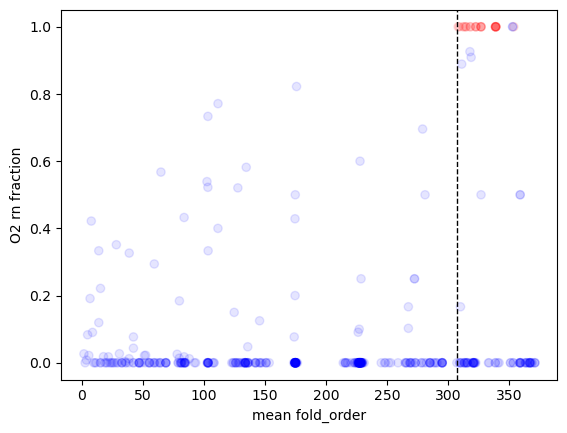

SAM (0.0732854527648615, '1.454728e-01')


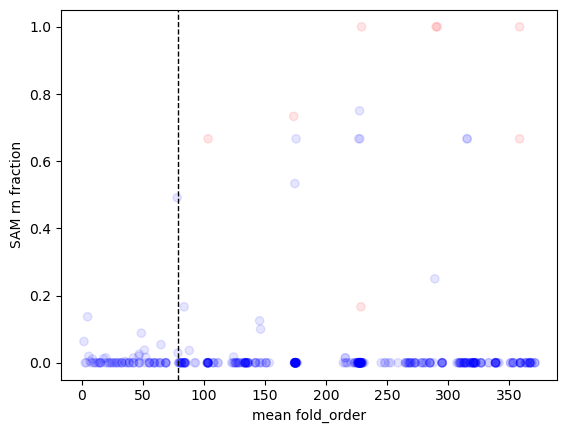

ATP (-0.014093526063696425, '7.797960e-01')


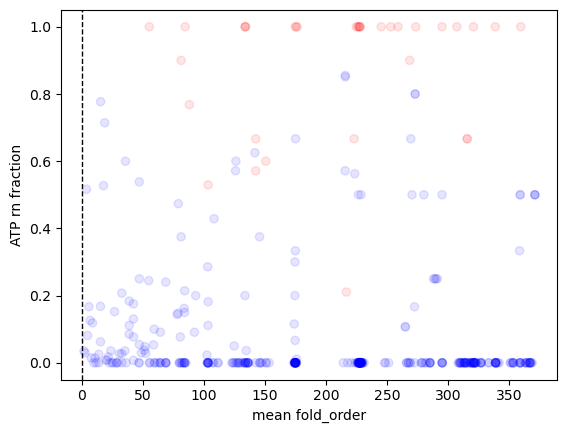

CoA (0.007932391516128635, '8.749642e-01')


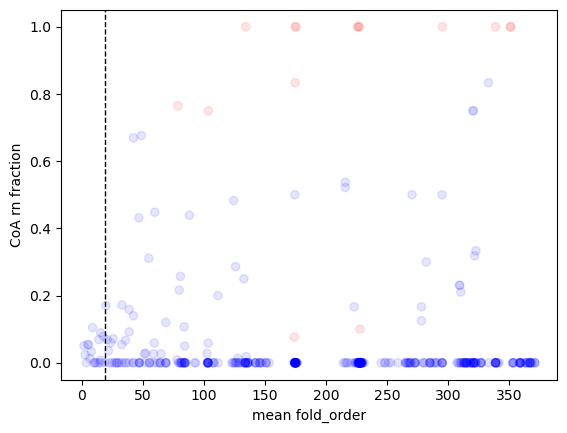

FAD (0.07302791314496607, '1.468967e-01')


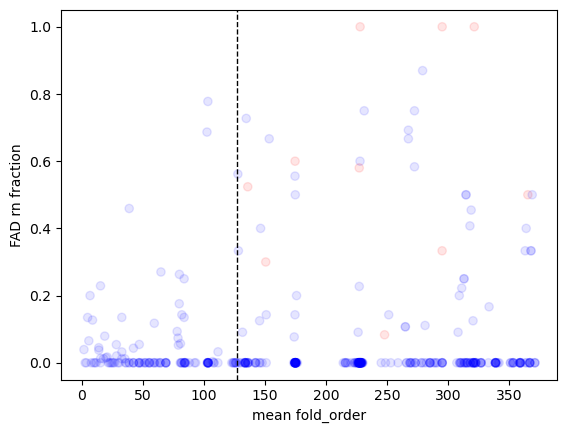

In [89]:
cofactorScatter('C00007', 'O2', x2rnFrac_O2_0, ETU_O2)
cofactorScatter('C00019', 'SAM', x2rnFrac_SAM_0, ETU_SAM)
cofactorScatter('C00002', 'ATP', x2rnFrac_ATP_0, ETU_ATP)
cofactorScatter('C00010', 'CoA', x2rnFrac_CoA_0, ETU_CoA)
cofactorScatter('C00016', 'FAD', x2rnFrac_FAD_0, ETU_FAD)

In [90]:
def getCategories(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc):
    emerge_to_use = set()  
    learn_to_use = set()
    unclassified = set()
    
    never_use_direct = set() # direct/total == 0
    never_use = set()  # direct/total == 0; indirect/total == 0; 'orthogonal'
    indirect_use = set() # direct/total == 0; indirect/total > 0

    for x, frac in x2rnFrac_cofactor_0.items():  # direct/total
        if frac == 0:
             never_use_direct.add(x)
        else:
            if x in etu:
                emerge_to_use.add(x)
            elif x in unc:
                unclassified.add(x)
            else:
                learn_to_use.add(x)  # here we don't check the direction...
    
    for x, frac in x2rnFrac_cofactor_1.items():  # indirect/total
        if x in never_use_direct and frac == 0:
             never_use.add(x)
        else:
            indirect_use.add(x)
    
    indirect_use_only = indirect_use - (emerge_to_use|learn_to_use|unclassified)
    return never_use, indirect_use_only, emerge_to_use, unclassified, learn_to_use

In [91]:
def drawPie(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc, title):
    never_use, indirect_use, emerge_to_use, unclassified, learn_to_use = getCategories(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc)
    
    labels = ['never_use', 'indirect_use', 'emerge_to_use', 'unclassified', 'learn_to_use']
    values = [len(never_use), len(indirect_use), len(emerge_to_use), len(unclassified), len(learn_to_use)]
    colors = ['gray', 'skyblue', 'red', '#f94449', 'pink']
#     hatches = ['', '', '', '.', '']

    fig, ax = plt.subplots(figsize=(4, 4))
    wedges, texts, autotexts = ax.pie(values, colors=colors, autopct=lambda p: '{:.0f}% ({:.0f})'.format(p, p * sum(values) / 100), startangle=90, labeldistance=1.05)
    plt.title(f'{title} n={sum(values)}')
    # plt.savefig(f'piechart_cofactor_{title}.svg', dpi=300, bbox_inches='tight')
    plt.show()

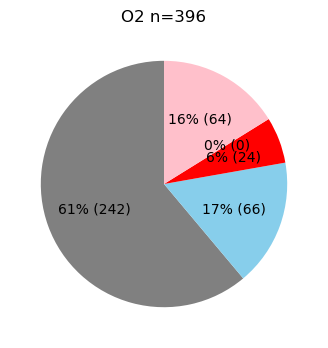

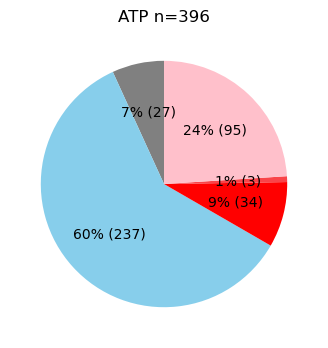

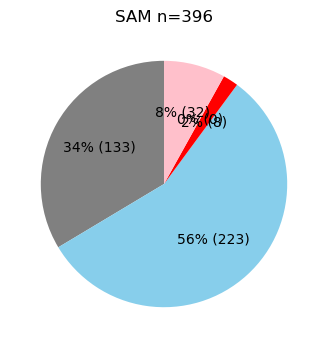

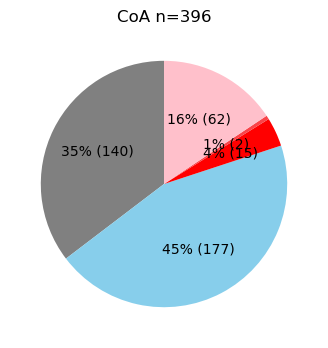

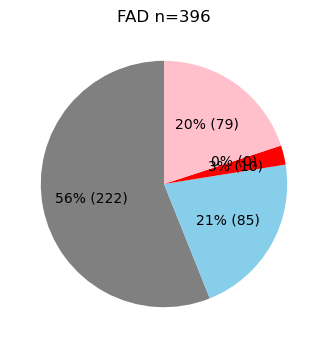

In [92]:
drawPie(x2rnFrac_O2_0, x2rnFrac_O2_1, ETU_O2, UC_O2, 'O2')
drawPie(x2rnFrac_ATP_0, x2rnFrac_ATP_1, ETU_ATP, UC_ATP, 'ATP')
drawPie(x2rnFrac_SAM_0, x2rnFrac_SAM_1, ETU_SAM, UC_SAM, 'SAM')
drawPie(x2rnFrac_CoA_0, x2rnFrac_CoA_1, ETU_CoA, UC_CoA, 'CoA')
drawPie(x2rnFrac_FAD_0, x2rnFrac_FAD_1, ETU_FAD, UC_FAD, 'FAD')

### stackplots instead

In [93]:
# Define categories, values, and colors
categories = ['never_use', 'indirect_use', 'emerge_to_use', 'unclassified', 'learn_to_use']
colors = ['gray', 'skyblue', 'red', '#f94449', 'pink']

In [94]:
NU_O2, IU_O2, ETU_O2, UC_O2, LTU_O2 =getCategories(x2rnFrac_O2_0, x2rnFrac_O2_1, ETU_O2, UC_O2)
NU_ATP, IU_ATP, ETU_ATP, UC_ATP, LTU_ATP =getCategories(x2rnFrac_ATP_0, x2rnFrac_ATP_1, ETU_ATP, UC_ATP)
NU_SAM, IU_SAM, ETU_SAM, UC_SAM, LTU_SAM =getCategories(x2rnFrac_SAM_0, x2rnFrac_SAM_1, ETU_SAM, UC_SAM)
NU_CoA, IU_CoA, ETU_CoA, UC_CoA, LTU_CoA =getCategories(x2rnFrac_CoA_0, x2rnFrac_CoA_1, ETU_CoA, UC_CoA)
NU_FAD, IU_FAD, ETU_FAD, UC_FAD, LTU_FAD =getCategories(x2rnFrac_FAD_0, x2rnFrac_FAD_1, ETU_FAD, UC_FAD)

NU_NAD, IU_NAD, ETU_NAD, UC_NAD, LTU_NAD =getCategories(x2rnFrac_NAD_0, x2rnFrac_NAD_1, ETU_NAD, UC_NAD)
NU_NADP, IU_NADP, ETU_NADP, UC_NADP, LTU_NADP =getCategories(x2rnFrac_NADP_0, x2rnFrac_NADP_1, ETU_NADP, UC_NADP)
NU_PLP, IU_PLP, ETU_PLP, UC_PLP, LTU_PLP =getCategories(x2rnFrac_PLP_0, x2rnFrac_PLP_1, ETU_PLP, UC_PLP)
NU_ThDP, IU_ThDP, ETU_ThDP, UC_ThDP, LTU_ThDP =getCategories(x2rnFrac_ThDP_0, x2rnFrac_ThDP_1, ETU_ThDP, UC_ThDP)

NU_IPP, IU_IPP, ETU_IPP, UC_IPP, LTU_IPP =getCategories(x2rnFrac_IPP_0, x2rnFrac_IPP_1, ETU_IPP, UC_IPP)
NU_FMN, IU_FMN, ETU_FMN, UC_FMN, LTU_FMN =getCategories(x2rnFrac_FMN_0, x2rnFrac_FMN_1, ETU_FMN, UC_FMN)
NU_Cobalamin, IU_Cobalamin, ETU_Cobalamin, UC_Cobalamin, LTU_Cobalamin =getCategories(x2rnFrac_Cobalamin_0, x2rnFrac_Cobalamin_1, ETU_Cobalamin, UC_Cobalamin)
NU_AcetylCoA, IU_AcetylCoA, ETU_AcetylCoA, UC_AcetylCoA, LTU_AcetylCoA =getCategories(x2rnFrac_AcetylCoA_0, x2rnFrac_AcetylCoA_1, ETU_AcetylCoA, UC_AcetylCoA)

In [95]:
print('    ETU   LTU   UC ')
print('------------------------')

print('O2  ', len(ETU_O2), '  ', len(LTU_O2), '  ', len(UC_O2))
print('ATP ', len(ETU_ATP), '  ', len(LTU_ATP), '  ', len(UC_ATP))
print('CoA  ', len(ETU_CoA), '  ', len(LTU_CoA), '  ', len(UC_CoA))
print('SAM ', len(ETU_SAM), '  ', len(LTU_SAM), '  ', len(UC_SAM))
print('FAD ', len(ETU_FAD), '  ', len(LTU_FAD), '  ', len(UC_FAD))
print('NAD ', len(ETU_NAD), '  ', len(LTU_NAD), '  ', len(UC_NAD))
print('NADP', len(ETU_NADP), '  ', len(LTU_NADP), '  ', len(UC_NADP))
print('PLP ', len(ETU_PLP), '  ', len(LTU_PLP), '  ', len(UC_PLP))
print('ThDP ', len(ETU_ThDP), '  ', len(LTU_ThDP), '  ', len(UC_ThDP))

    ETU   LTU   UC 
------------------------
O2   24    64    0
ATP  34    95    3
CoA   15    62    2
SAM  8    32    0
FAD  10    79    0
NAD  12    114    1
NADP 14    104    2
PLP  8    33    0
ThDP  2    20    0


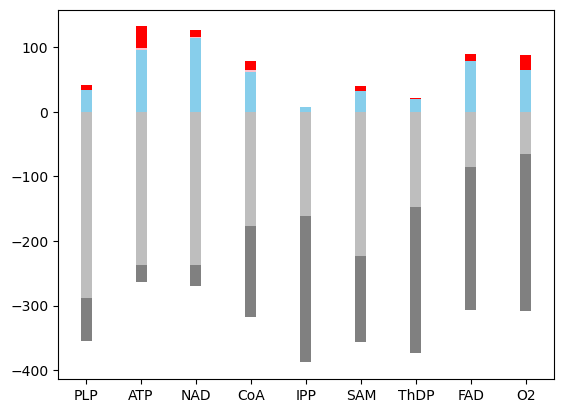

In [96]:
# a = [-len(IU_PLP), -len(IU_ATP), -len(IU_NAD), -len(IU_NADP), -len(IU_CoA), -len(IU_AcetylCoA), -len(IU_IPP), -len(IU_SAM), -len(IU_ThDP), -len(IU_FAD), -len(IU_FMN), -len(IU_Cobalamin), -len(IU_O2)] 
# b = [-len(NU_PLP), -len(NU_ATP), -len(NU_NAD), -len(NU_NADP), -len(NU_CoA), -len(NU_AcetylCoA), -len(NU_IPP), -len(NU_SAM), -len(NU_ThDP), -len(NU_FAD),  -len(NU_FMN), -len(NU_Cobalamin), -len(NU_O2)]  
# c = [len(LTU_PLP), len(LTU_ATP), len(LTU_NAD), len(LTU_NADP), len(LTU_CoA), len(LTU_AcetylCoA), len(LTU_IPP), len(LTU_SAM), len(LTU_ThDP), len(LTU_FAD), len(LTU_FMN),  len(LTU_Cobalamin), len(LTU_O2)]
# d = [len(UC_PLP), len(UC_ATP), len(UC_NAD), len(UC_NADP), len(UC_CoA), len(UC_AcetylCoA), len(UC_IPP), len(UC_SAM), len(UC_ThDP), len(UC_FAD), len(UC_FMN), len(UC_Cobalamin), len(UC_O2)]
# e = [len(ETU_PLP), len(ETU_ATP), len(ETU_NAD), len(ETU_NADP), len(ETU_CoA), len(ETU_AcetylCoA), len(ETU_IPP), len(ETU_SAM), len(ETU_ThDP), len(ETU_FAD), len(ETU_FMN),  len(ETU_Cobalamin), len(ETU_O2)]

a = [-len(IU_PLP), -len(IU_ATP), -len(IU_NAD), -len(IU_CoA), -len(IU_IPP), -len(IU_SAM), -len(IU_ThDP), -len(IU_FAD), -len(IU_O2)] 
b = [-len(NU_PLP), -len(NU_ATP), -len(NU_NAD), -len(NU_CoA), -len(NU_IPP), -len(NU_SAM), -len(NU_ThDP), -len(NU_FAD), -len(NU_O2)]  
c = [len(LTU_PLP), len(LTU_ATP), len(LTU_NAD), len(LTU_CoA), len(LTU_IPP), len(LTU_SAM), len(LTU_ThDP), len(LTU_FAD), len(LTU_O2)]
d = [len(UC_PLP), len(UC_ATP), len(UC_NAD), len(UC_CoA), len(UC_IPP), len(UC_SAM), len(UC_ThDP), len(UC_FAD), len(UC_O2)]
e = [len(ETU_PLP), len(ETU_ATP), len(ETU_NAD), len(ETU_CoA), len(ETU_IPP), len(ETU_SAM), len(ETU_ThDP), len(ETU_FAD), len(ETU_O2)]


data = np.array([a, b, c, d, e])
# data = np.array([a, c, d, e])
data_shape = np.shape(data)

# Take negative and positive data apart and cumulate
def get_cumulated_array(data, **kwargs):
    cum = data.clip(**kwargs)
    cum = np.cumsum(cum, axis=0)
    d = np.zeros(np.shape(data))
    d[1:] = cum[:-1]
    return d  

cumulated_data = get_cumulated_array(data, min=0)
cumulated_data_neg = get_cumulated_array(data, max=0)

# Re-merge negative and positive data.
row_mask = (data<0)
cumulated_data[row_mask] = cumulated_data_neg[row_mask]
data_stack = cumulated_data

cols = ["#bebebe", "gray", "skyblue", "pink", 'red']
# cols = ["skyblue", "pink", "orange", 'red']

fig = plt.figure()
ax = plt.subplot(111)

bar_width = 0.2  # Adjust this value to make the bars narrower

for i in np.arange(0, data_shape[0]):
    ax.bar(np.arange(data_shape[1]), data[i], bottom=data_stack[i], color=cols[i], width=bar_width)

# Custom x-axis labels
# x_labels = ['PLP', 'ATP', 'NAD', 'NADP', 'CoA', 'A-CoA', 'IPP', 'SAM', 'ThDP', 'FAD', 'FMN', 'Cobalamin', 'O2']  # Replace with your custom labels
x_labels = ['PLP', 'ATP', 'NAD', 'CoA', 'IPP', 'SAM', 'ThDP', 'FAD', 'O2']  # Replace with your custom labels
ax.set_xticks(np.arange(data_shape[1]))
ax.set_xticklabels(x_labels)

# plt.savefig('cofactor_stacked_bars.svg', dpi=300, bbox_inches='tight')
# plt.savefig('cofactor_stacked_bars_no_neveruse.svg', dpi=300, bbox_inches='tight')
plt.show()

### intersections of ETU folds (STRICT)

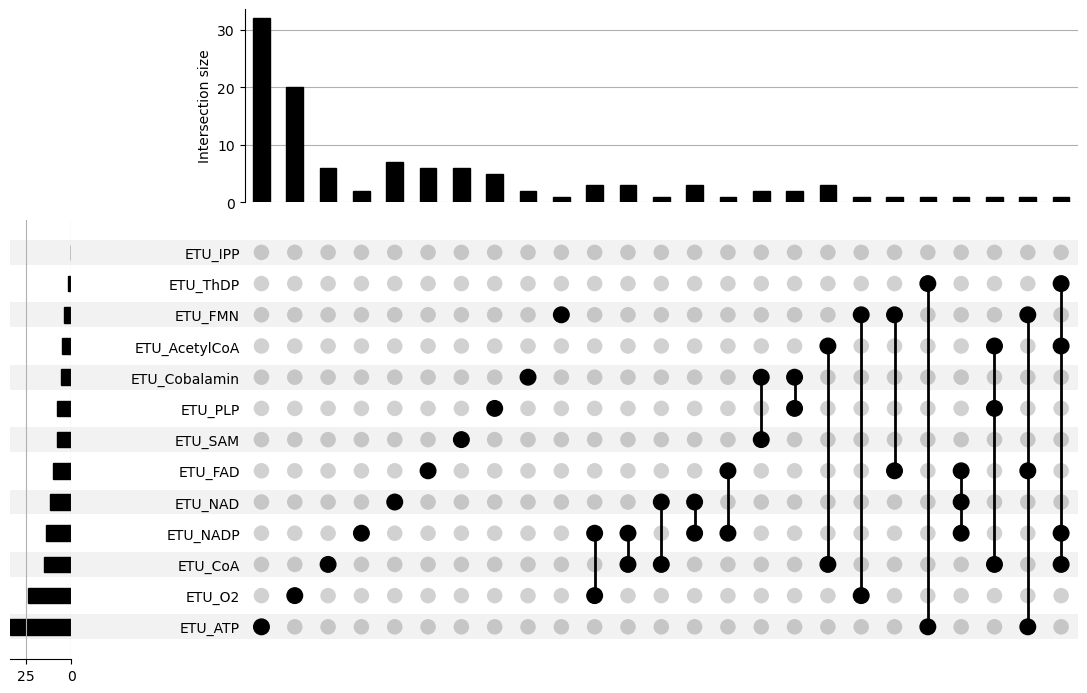

In [97]:
# Create a dictionary with all sets
sets = {
    'ETU_O2': ETU_O2,
    'ETU_ATP': ETU_ATP,
    'ETU_CoA': ETU_CoA,
    'ETU_SAM': ETU_SAM,
    'ETU_FAD': ETU_FAD,
    'ETU_NAD': ETU_NAD,
    'ETU_NADP': ETU_NADP,
    'ETU_PLP': ETU_PLP,
    'ETU_ThDP': ETU_ThDP,
    'ETU_FMN': ETU_FMN,
    'ETU_IPP': ETU_IPP,
    'ETU_Cobalamin': ETU_Cobalamin,
    'ETU_AcetylCoA': ETU_AcetylCoA
}

# Generate DataFrame suitable for UpSet plot
all_elements = set.union(*sets.values())
data = {elem: [elem in sets[set_name] for set_name in sets] for elem in all_elements}

# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=sets.keys())

# Create a MultiIndex from boolean DataFrame
df.index = pd.MultiIndex.from_frame(df.astype(bool).reset_index(drop=True))

# Filter out self-intersections
# df = df[df.sum(axis=1) > 1]

# Aggregate the data by the MultiIndex to get counts
df_counts = df.groupby(level=list(df.index.names)).size()

# Create the UpSet plot
upset = UpSet(df_counts)
upset.plot()
plt.show()

In [98]:
ETU_FAD & ETU_ATP, ETU_FAD & ETU_O2, ETU_SAM & ETU_ATP

({'7541'}, set(), set())

### intersections of LTU folds (LOOSE)

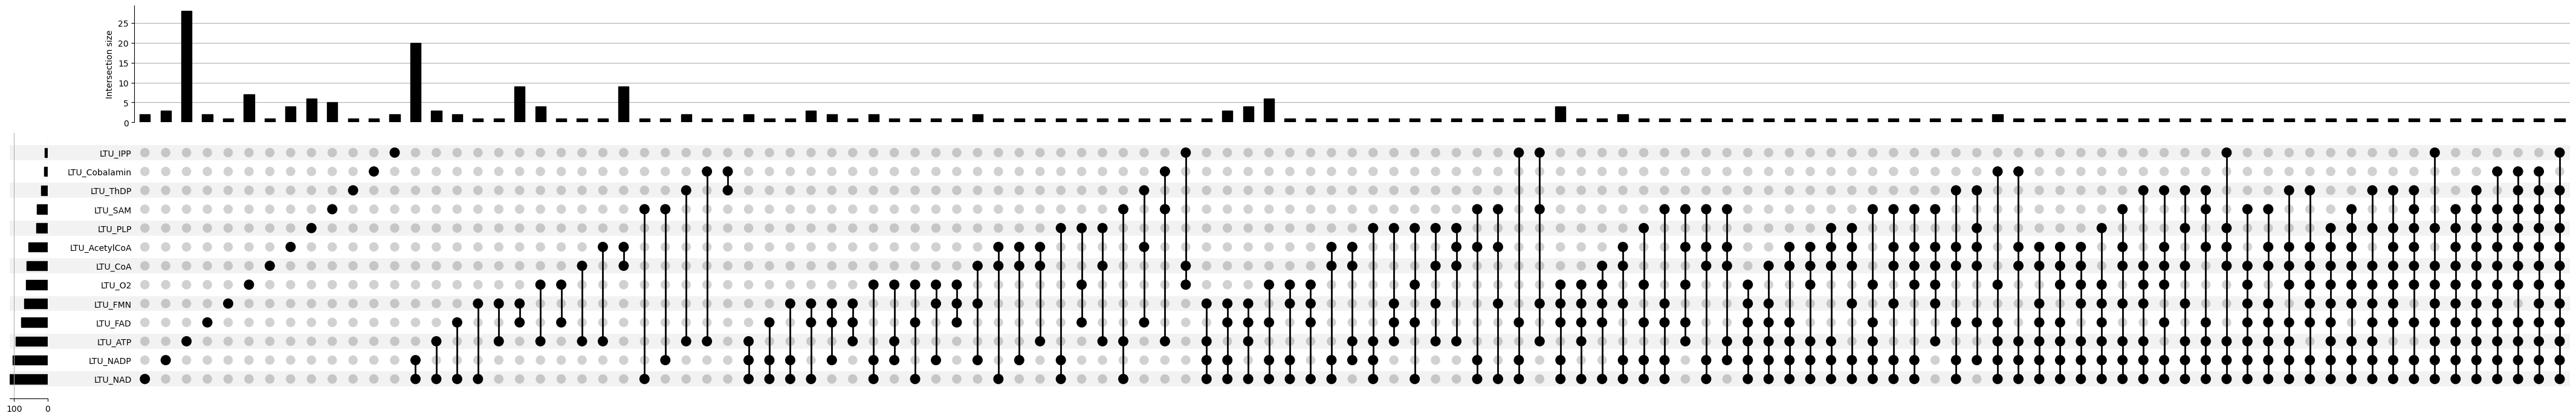

In [99]:
# Create a dictionary with all sets
sets = {
    'LTU_O2': LTU_O2,
    'LTU_ATP': LTU_ATP,
    'LTU_CoA': LTU_CoA,
    'LTU_SAM': LTU_SAM,
    'LTU_FAD': LTU_FAD,
    'LTU_NAD': LTU_NAD,
    'LTU_NADP': LTU_NADP,
    'LTU_PLP': LTU_PLP,
    'LTU_ThDP': LTU_ThDP,
    'LTU_FMN': LTU_FMN,
    'LTU_IPP': LTU_IPP,
    'LTU_Cobalamin': LTU_Cobalamin,
    'LTU_AcetylCoA': LTU_AcetylCoA
}

# Generate DataFrame suitable for UpSet plot
all_elements = set.union(*sets.values())
data = {elem: [elem in sets[set_name] for set_name in sets] for elem in all_elements}

# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=sets.keys())

# Create a MultiIndex from boolean DataFrame
df.index = pd.MultiIndex.from_frame(df.astype(bool).reset_index(drop=True))

# Filter out self-intersections
# df = df[df.sum(axis=1) > 1]

# Aggregate the data by the MultiIndex to get counts
df_counts = df.groupby(level=list(df.index.names)).size()

# Create the UpSet plot
upset = UpSet(df_counts)
upset.plot()
plt.show()

### look for all cpds for high-ETU/LTU cpds

In [100]:
# # this takes a while if you use getETU_UC_C

# cpd2ETUfolds = {}
# cpd2LTUfolds = {}
# for cpd in result.scope.cpds:  # for all compounds discovered in our simulation
#     print(len(cpd2ETUfolds), cpd)  # log for progress
    
#     # get ETU folds
#     direct_cofactor_rn_set = getDirectRns(cpd) & set(result.scope.rns)  # get direct cpd-using reactions within scope
#     if cpd.startswith('C'):
#         ETU, UC = getETU_UC_C(cpd, direct_cofactor_rn_set)
#     else:
#         ETU, UC = getETU_UC(direct_cofactor_rn_set)
#     cpd2ETUfolds[cpd] = ETU

#     # get LTU folds
#     directFolds = set()
#     for x, rns in x2rn_scope.items():  # check each fold and their reactions
#         for rn in rns:
#             if rn in direct_cofactor_rn_set:  # if 1+ rns exist with cofactor
#                 directFolds.add(x)
#                 break
#     cpd2LTUfolds[cpd] = directFolds - ETU

# dict2csv(cpd2ETUfolds, '../data/assets/cpd2ETUfolds_preATP_getETU_UC_C_strict.csv')
# dict2csv(cpd2LTUfolds, '../data/assets/cpd2LTUfolds_preATP_getETU_UC_C_strict.csv')

0 C11955
1 C06616
2 C05589
3 C01724
4 C19814
5 C00544
6 C20530
7 C22318
8 C01158
9 C20198
10 C16622
11 C15992
12 C21889
13 C07481
14 C06426
15 C02488
16 C04248
17 C20644
18 C16322
19 C01586
20 Z00024
21 Z00061
22 C21106
23 C01737
24 C17883
25 C06892
26 C00463
27 C02355
28 C07578
29 C00243
30 C02091
31 C00804
32 C11818
33 C00906
34 C00791
35 C16461
36 C05607
37 C20252
38 C00342
39 C04631
40 C06074
41 C06035
42 C00439
43 C13431
44 C00879
45 C00218
46 C20403
47 C06737
48 C00630
49 C15777
50 C20850
51 C09684
52 C05161
53 C06400
54 C02989
55 C00180
56 C06257
57 Z00023
58 C20158
59 C05359
60 C22264
61 C06423
62 C05810
63 C02265
64 C00332
65 C00028
66 C21170
67 C00836
68 C21028
69 C03354
70 C20274
71 C20729
72 C20692
73 C00722
74 C21661
75 C22343
76 C01613
77 C02532
78 C22368
79 C21893
80 C01893
81 C02800
82 C00030
83 C01424
84 C02576
85 C00674
86 C00433
87 C16499
88 C06311
89 C00689
90 C01596
91 C02669
92 C05399
93 C14180
94 C11830
95 C12203
96 C02670
97 C21613
98 C05919
99 C22325
100 C01888

In [107]:
cpd2ETUfolds = csv2dict('../data/assets/cpd2ETUfolds_preATP_getETU_UC_C_strict.csv')
cpd2LTUfolds = csv2dict('../data/assets/cpd2LTUfolds_preATP_getETU_UC_C_strict.csv')

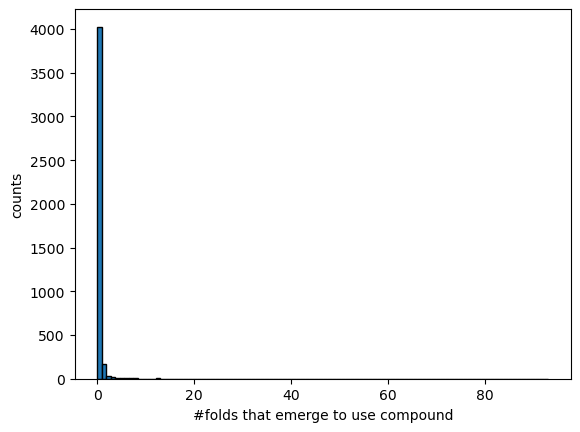

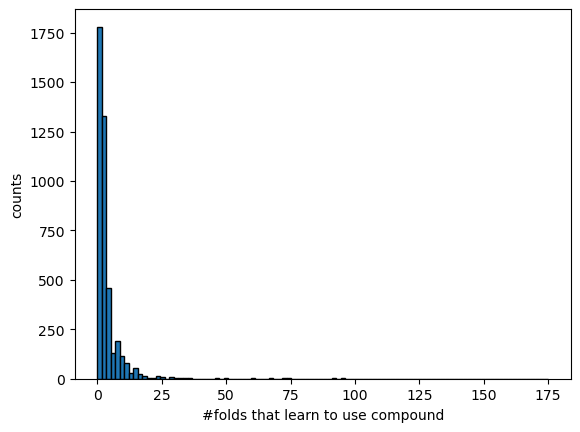

In [109]:
cpd2ETUfoldsNum = {k:len(v) for k,v in cpd2ETUfolds.items()}
cpd2LTUfoldsNum = {k:len(v) for k,v in cpd2LTUfolds.items()}
histogram(cpd2ETUfoldsNum, bins=100, x_axis='#folds that emerge to use compound')
histogram(cpd2LTUfoldsNum, bins=100, x_axis='#folds that learn to use compound')

In [122]:
# top LTU cpds
{(cpd2name.get(k, 'no name'), k): v for k, v in sorted(cpd2LTUfoldsNum.items(), key=lambda item: item[1], reverse=True)}

{('H2O', 'C00001'): 175,
 ('Mg', 'Z00029'): 156,
 ('Mn', 'Z00030'): 143,
 ('H+', 'C00080'): 133,
 ('Zinc', 'Z00054'): 117,
 ('CO2', 'C00011'): 100,
 ('ATP', 'C00002'): 96,
 ('NAD+', 'C00003'): 96,
 ('NADP+', 'C00006'): 92,
 ('NADH', 'C00004'): 92,
 ('Orthophosphate', 'C00009'): 91,
 ('Iron', 'Z00015'): 91,
 ('NADPH', 'C00005'): 88,
 ('Ammonia', 'C00014'): 82,
 ('FAD', 'Z00013'): 78,
 ('ADP', 'C00008'): 74,
 ('Diphosphate', 'C00013'): 74,
 ('Flavoprotein', 'Z00019'): 72,
 ('Divalent Metal (M2)', 'Z00069'): 72,
 ('Cobalt', 'Z00006'): 72,
 ('Calcium', 'Z00055'): 70,
 ('CoA', 'C00010'): 69,
 ('4Fe4S', 'Z00002'): 68,
 ('AMP', 'C00020'): 67,
 ('NAD/NADP', 'Z00032'): 67,
 ('Oxygen', 'C00007'): 64,
 ('FMN', 'Z00014'): 62,
 ('Generic FeS', 'Z00063'): 61,
 ('Acetyl-CoA', 'C00024'): 60,
 ('L-Glutamate', 'C00025'): 50,
 ('Oxidized ferredoxin', 'C00139'): 49,
 ('Reduced ferredoxin', 'C00138'): 49,
 ('Nickel', 'Z00034'): 49,
 ('Heme', 'Z00025'): 46,
 ('Pyruvate', 'C00022'): 46,
 ('Hydrogen peroxide'

In [102]:
# for 93% of cpd, they have ZERO folds that ETU that cpd

print(list(cpd2ETUfoldsNum.values()).count(0))
print(list(cpd2ETUfoldsNum.values()).count(0)/len(cpd2ETUfoldsNum))

4026
0.9375873311597578


In [124]:
# top ETU cpds
{(cpd2name.get(k, 'no name'), k): v for k, v in sorted(cpd2ETUfoldsNum.items(), key=lambda item: item[1], reverse=True)}

{('H2O', 'C00001'): 93,
 ('H+', 'C00080'): 41,
 ('ATP', 'C00002'): 32,
 ('Oxygen', 'C00007'): 24,
 ('ADP', 'C00008'): 19,
 ('CO2', 'C00011'): 18,
 ('Iron', 'Z00015'): 15,
 ('Orthophosphate', 'C00009'): 13,
 ('Mg', 'Z00029'): 13,
 ('Diphosphate', 'C00013'): 13,
 ('Heme', 'Z00025'): 12,
 ('NADPH', 'C00005'): 11,
 ('Zinc', 'Z00054'): 11,
 ('Nickel', 'Z00034'): 9,
 ('PLP', 'Z00035'): 8,
 ('4Fe4S', 'Z00002'): 8,
 ('Generic FeS', 'Z00063'): 8,
 ('NADH', 'C00004'): 8,
 ('CoA', 'C00010'): 8,
 ('NAD+', 'C00003'): 8,
 ('FAD', 'Z00013'): 7,
 ('Ammonia', 'C00014'): 7,
 ('Hydrogen', 'C00282'): 7,
 ('NADP+', 'C00006'): 7,
 ('Oxidized ferredoxin', 'C00139'): 7,
 ('Reduced ferredoxin', 'C00138'): 7,
 ('AMP', 'C00020'): 6,
 ('L-Glutamate', 'C00025'): 6,
 ('Cobalamin', 'Z00009'): 6,
 ('S-Adenosyl-L-methionine', 'C00019'): 6,
 ('Reduced acceptor', 'C00030'): 5,
 ('Coenzyme F420', 'C00876'): 5,
 ('Formate', 'C00058'): 5,
 ('Flavoprotein', 'Z00019'): 5,
 ('L-Serine', 'C00065'): 5,
 ('Thioredoxin', 'C00342'

### ***look for cofactor-switching in folds

- For major cofactrs, we have ETU and LTU defined by C+Z compounds.
- Let's use these sets to look for patterns of initial cofactor use vs. learning over time.
- Let's also add more cofactors that are drivers of fold evolution as we saw above

In [106]:
# C+Z
print("CoA:    ", cpd2ETUfoldsNum['C00010'], cpd2ETUfoldsNum['Z00051']) 
print("SAM:    ", cpd2ETUfoldsNum['C00019'], cpd2ETUfoldsNum['Z00041'])
print("PLP:    ", cpd2ETUfoldsNum['C00018'], cpd2ETUfoldsNum['Z00035'])
print("ThDP:   ", cpd2ETUfoldsNum['C00068'], cpd2ETUfoldsNum['Z00047'])

# C or Z
print("Cobalam:", cpd2ETUfoldsNum['Z00009'])
print("Ace-CoA:", cpd2ETUfoldsNum['C00024']) 
print("IPP:    ", cpd2ETUfoldsNum['C00129']) 

# 2C
print("ATP/ADP:", cpd2ETUfoldsNum['C00002'], cpd2ETUfoldsNum['C00008'])

# 2C + Z
print("FAD:    ", cpd2ETUfoldsNum['C00016'], cpd2ETUfoldsNum['Z00013'], cpd2ETUfoldsNum['C01352'])
print("FMN:    ", cpd2ETUfoldsNum['C00061'], cpd2ETUfoldsNum['Z00014'], cpd2ETUfoldsNum['C01847'])
print("NAD:    ", cpd2ETUfoldsNum['C00003'], cpd2ETUfoldsNum['Z00032'], cpd2ETUfoldsNum['C00004'])
print("NADP:   ", cpd2ETUfoldsNum['C00005'], cpd2ETUfoldsNum['Z00032'], cpd2ETUfoldsNum['C00006'])

CoA:     8 0
SAM:     6 2
PLP:     0 8
ThDP:    1 1
Cobalam: 6
Ace-CoA: 3
IPP:     0
ATP/ADP: 32 19
FAD:     1 7 0
FMN:     1 3 0
NAD:     8 3 8
NADP:    11 3 7


In [ ]:
"""
('Iron', 'Z00015'): 15,
 ('Diphosphate', 'C00013'): 13,
 ('Mg', 'Z00029'): 13,
 ('Orthophosphate', 'C00009'): 13,
 ('Heme', 'Z00025'): 12,
 ('Zinc', 'Z00054'): 11,
 ('Nickel', 'Z00034'): 9,
 ('Generic FeS', 'Z00063'): 8,
 
 ('4Fe4S', 'Z00002'): 8,
 ('Oxidized ferredoxin', 'C00139'): 7,
 ('Reduced ferredoxin', 'C00138'): 7,
 
 ('Ammonia', 'C00014'): 7,
 ('L-Glutamate', 'C00025'): 6,
 ('L-Serine', 'C00065'): 5,
 ('Coenzyme F420', 'C00876'): 5,
 ('Formate', 'C00058'): 5,
 ('Flavoprotein', 'Z00019'): 5,
 """

In [ ]:
# Create a dictionary with all sets
sets = {
    'ETU_Iron': cpd2ETUfolds['Z00015'],
    'ETU_PPi': cpd2ETUfolds['C00013'],
    'ETU_Mg': cpd2ETUfolds['Z00029'],
    'ETU_Pi': cpd2ETUfolds['C00009'],
    'ETU_Heme': cpd2ETUfolds['Z00025'],
    'ETU_Zinc': cpd2ETUfolds['Z00054'],
    'ETU_Nickel': cpd2ETUfolds['Z00034'],
    'ETU_Gen_FeS': cpd2ETUfolds['Z00063'],
    'ETU_4Fe4S': cpd2ETUfolds['Z00002'],
    'ETU_oxFerr': cpd2ETUfolds['C00139'],
    'ETU_reFerr': cpd2ETUfolds['C00138'],
    'ETU_NH3': cpd2ETUfolds['C00014'],
    'ETU_Glu': cpd2ETUfolds['C00025'],
    'ETU_Ser': cpd2ETUfolds['C00065'],
    'ETU_F420': cpd2ETUfolds['C00876'],
    'ETU_Formate': cpd2ETUfolds['C00058'],
    'ETU_Flavo': cpd2ETUfolds['Z00019'],
}

# Generate DataFrame suitable for UpSet plot
all_elements = set.union(*sets.values())
data = {elem: [elem in sets[set_name] for set_name in sets] for elem in all_elements}

# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=sets.keys())

# Create a MultiIndex from boolean DataFrame
df.index = pd.MultiIndex.from_frame(df.astype(bool).reset_index(drop=True))

# Filter out self-intersections
# df = df[df.sum(axis=1) > 1]

# Aggregate the data by the MultiIndex to get counts
df_counts = df.groupby(level=list(df.index.names)).size()

# Create the UpSet plot
upset = UpSet(df_counts)
upset.plot()
plt.show()

In [ ]:
# Create a dictionary with all sets
sets = {
    'ETU_PLP': ETU_PLP,
    'ETU_ATP': ETU_ATP,
    'ETU_NAD': ETU_NAD,
    'ETU_CoA': ETU_CoA,
    'ETU_SAM': ETU_SAM,
    'ETU_FAD': ETU_FAD,
    'ETU_O2': ETU_O2,
}

# Generate DataFrame suitable for UpSet plot
all_elements = set.union(*sets.values())
data = {elem: [elem in sets[set_name] for set_name in sets] for elem in all_elements}

# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=sets.keys())

# Create a MultiIndex from boolean DataFrame
df.index = pd.MultiIndex.from_frame(df.astype(bool).reset_index(drop=True))

# Filter out self-intersections
# df = df[df.sum(axis=1) > 1]

# Aggregate the data by the MultiIndex to get counts
df_counts = df.groupby(level=list(df.index.names)).size()

# Create the UpSet plot
upset = UpSet(df_counts)
upset.plot()
plt.show()

In [ ]:
cofactor2ETUfolds = {'PLP':ETU_PLP, 'ATP':ETU_ATP, 'NAD':ETU_NAD, 'CoA':ETU_CoA, 'SAM':ETU_SAM, 'FAD':ETU_FAD, 'O2':ETU_O2_C}
cofactor2LTUfolds = {'PLP':LTU_PLP, 'ATP':LTU_ATP, 'NAD':LTU_NAD, 'CoA':LTU_CoA, 'SAM':LTU_SAM, 'FAD':LTU_FAD, 'O2':LTU_O2}

x2cofactors = {}
for x in x2ns.keys():
    ETU_cpds = []
    LTU_cpds = []
    for c_name in cofactor2ETUfolds.keys():  # 'PLP', 'ATP', 'NAD', 'CoA', 'IPP', 'SAM', 'ThDP', 'FAD', 'O2'
        if x in cofactor2ETUfolds[c_name]:
            ETU_cpds.append(c_name)
        if x in cofactor2LTUfolds[c_name]:
            LTU_cpds.append(c_name)
    print(f"{x} 'emerge to use:' {ETU_cpds}, 'learn to use:' {LTU_cpds}")
    x2cofactors[x] = frozenset(ETU_cpds + LTU_cpds)

In [ ]:
d = dict(Counter(x2cofactors.values()))
dict(sorted(d.items(), key=lambda x: x[1], reverse=True))

In [ ]:
x2numCofactors = {k:len(v) for k,v in x2cofactors.items()}
# dict2csv(x2numCofactors, '../data/assets/xgroup2/x2numCofactors.csv')
histogram(x2numCofactors, bins=50, x_axis='# cofactors associated with a fold')

# 3. fold reuse timing

## rn2ec

In [ ]:
rn2ec = csv2dict('../data/assets/rn2ec.csv')

In [ ]:
x2rn_ec1 = {}
x2rn_ec2 = {}
for x, rns in x2rn.items():
    ec_list1 = []
    ec_list2 = []
    for rn in rns:
        if rn2ec.get(rn[:6], 0) == 0:  # not in rn2ec
            ec_list1.append('0')
        else:
            ec_list1.append(rn2ec[rn[:6]].split('.')[0])
            ec_list2.append(rn2ec[rn[:6]].split('.')[0] + '.' + rn2ec[rn[:6]].split('.')[1])
    x2rn_ec1[x] = ec_list1
    x2rn_ec2[x] = ec_list2

In [ ]:
x2rn_ec1[x].count('1')

In [ ]:
def drawPie_ec(x, x2rn_ec):
    
    labels = ['0', '1', '2', '3', '4', '5', '6']
    values = [x2rn_ec1[x].count('0'), x2rn_ec1[x].count('1'), x2rn_ec1[x].count('2'), x2rn_ec1[x].count('3'), x2rn_ec1[x].count('4'), x2rn_ec1[x].count('5'), x2rn_ec1[x].count('6')]
    colors = ['gray', '#5B4DB7', '#42ADC7', '#81D152', '#F5F263', '#FF9D4F', '#FF5347']

    fig, ax = plt.subplots(figsize=(4, 4))
    wedges, texts, autotexts = ax.pie(values, labels = labels, colors=colors, autopct=lambda p: '{:.0f}% ({:.0f})'.format(p, p * sum(values) / 100), startangle=90, labeldistance=1.05)
    plt.title(f'{x} n={sum(values)}')
    # plt.savefig(f'piechart_cofactor_{title}.svg', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# 1: oxidoreductase
# 2. transferease
# 3. Hydrolase
# 4. Lyase
# 5. isomerase
# 6. Translocase

In [ ]:
for x in group1:
    drawPie_ec(x, x2rn_ec1)

## back to usage timing

In [ ]:
# fastest run
# result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-07-08_10-50-55_no_lookahead_preExpansion_C00002_67543.pkl.gz')

In [ ]:
rule2fo = {}
for key, value in result.rules_folditer.items():
    if key[1] not in rule2fo.keys():
        rule2fo[key[1]] = [value]
    else:
        rule2fo[key[1]].append(value)

folditer2rules = {}
for key , values in rule2fo.items():
    for value in values:
        if value not in folditer2rules.keys():
            folditer2rules[value] = [key]
        else:
            folditer2rules[value].append(key)
        
x2usage = {x:set() for x in result.folds_folditer.keys()}  # empty dict
x2usage.pop('fold_independent')
x2usage.pop('spontaneous')

for i, rules in folditer2rules.items():
    for rule in rules:
        for x in rule:
            if x in x2usage: # ignore 'fold_independent' and 'spontaneous'
                x2usage[x].add(i)  # don't record multiple usage within one fold_iter
x2usage = {x:sorted(list(s)) for x,s in x2usage.items()}

In [ ]:
folditer2reactionRules = {}
for key , fo in result.rules_folditer.items():
        if fo not in folditer2reactionRules.keys():
            folditer2reactionRules[fo] = [key]
        else:
            folditer2reactionRules[fo].append(key)
            
x2usage_ec1 = {x:[] for x in result.folds_folditer.keys()}  # empty dict
x2usage_ec1.pop('fold_independent')
x2usage_ec1.pop('spontaneous')
x2usage_ec2 = {x:[] for x in result.folds_folditer.keys()}  # empty dict
x2usage_ec2.pop('fold_independent')
x2usage_ec2.pop('spontaneous')

for i, rrs in folditer2reactionRules.items():
    for rr in rrs:
        for x in rr[1]:
            if x in x2usage_ec1: # ignore 'fold_independent' and 'spontaneous'
                x2usage_ec1[x].append([i, rn2ec.get(rr[0], '0.0')[0]])
                x2usage_ec2[x].append([i, rn2ec.get(rr[0], '0.0')[0:3]])

In [ ]:
notinrn2ec = []
for rn in result.scope.rns:
    if rn[:6] not in rn2ec.keys():
        notinrn2ec.append(rn)
print(len(notinrn2ec), len(result.scope.rns), len(rn2ec.keys()))

## duration

In [ ]:
x2usage_first_last = {key: [min(values), max(values)] for key, values in x2usage.items()}

In [ ]:
# remove folds with duration = 0
single_use_folds = set()
x2usage_first_lastNoSingles = {}

for x , usage in x2usage_first_last.items():
    if usage[1]-usage[0] != 0:
        x2usage_first_lastNoSingles[x] = usage
    else:
        single_use_folds.add(x)
print(len(x2usage_first_last) - len(x2usage_first_lastNoSingles))

In [ ]:
single_use_folds & set(group1)

In [ ]:
# Preparing data for plotting
data = x2usage_first_lastNoSingles

keys = list(data.keys())
y_positions = range(len(keys))

# color by new ec invention
notches = {}
for fold in x2usage_first_lastNoSingles.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec2[fold]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    current_ecs = set()
    for fo, ecs in fo2ec.items():
        if ecs - current_ecs != set() and current_ecs != set():
            if fold not in notches:
                notches[fold] = [fo]
            else:
                notches[fold].append(fo)
        current_ecs = current_ecs | ecs


plt.figure(figsize=(10, 30))

# Plotting lines first
for i, key in enumerate(keys):
    values = data[key]
    plt.plot(values, [key, key], marker='o', color='skyblue', zorder=1)
    plt.text(values[1] + 2, key, f'{keys[i]}', fontsize=8, zorder=2)

# Adding notches after plotting the lines
for i, key in enumerate(keys):
    notch_positions = notches.get(key, [])  # Get notches for the current key
    for notch in notch_positions:
        plt.scatter(notch, key, color='red', marker='|', zorder=3)  # Change marker shape here

# Adding labels
plt.xlabel('first and last fold usage')
plt.ylabel('folds')
plt.yticks(ticks=y_positions, labels=keys, fontsize=8)
plt.ylim([220, -3])

# plt.savefig('fold_usage_duration_ec2.svg', dpi=300, bbox_inches='tight')
plt.show()

## Lazurus (zombie) folds

In [ ]:
# remove single-use folds
x2usageNoSingles = {}
for x , usage in x2usage.items():
    if x in x2usage_first_lastNoSingles.keys():
        x2usageNoSingles[x] = usage
print(len(x2usage) - len(x2usageNoSingles))

x2usage_secondLast_last = {}
for key, values in x2usageNoSingles.items():
    x2usage_secondLast_last[key] = [sorted(values)[-2], sorted(values)[-1]]
    
    
def largest_gap(sorted_numbers):    
    # Initialize variables to track the largest gap and the corresponding pair
    largest_gap = 0
    largest_gap_pair = (None, None)
    
    # Compute the differences between consecutive elements
    for i in range(len(sorted_numbers) - 1):
        gap = sorted_numbers[i + 1] - sorted_numbers[i]
        if gap > largest_gap:
            largest_gap = gap
            largest_gap_pair = [sorted_numbers[i], sorted_numbers[i + 1]]
    
    return largest_gap_pair    

x2longestSleep = {}
for key, values in x2usageNoSingles.items():
    x2longestSleep[key] = largest_gap(values)

In [ ]:
data = x2usage_first_lastNoSingles
keys = list(data.keys())
y_positions = range(len(keys))

plt.figure(figsize=(10, 30))

# Plotting lines
for i, key in enumerate(keys):
    values = data[key]
    plt.plot(values, [key, key], marker='o', color='skyblue', zorder=1)
    plt.text(values[1] + 2, key, f'{keys[i]}', fontsize=8, zorder=3)

# Plotting 'sleep' lines
data = x2longestSleep
keys = list(data.keys())
for i, key in enumerate(keys):
    values = data[key]
    plt.plot(values, [key, key], marker='o', color='purple', zorder=2)
    


# Adding labels
plt.xlabel('second-last and last fold usage')
plt.ylabel('folds')
plt.yticks(ticks=y_positions, labels=keys, fontsize=8)
plt.ylim([220, -3])
plt.xlim([0, 399])

# plt.savefig('lazarus_zombie_longest_sleep.svg', dpi=300, bbox_inches='tight')
plt.show()

## dot per use

In [ ]:
data = x2usageNoSingles

# color by new ec invention
colors = []
for fold in x2usageNoSingles.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec2[fold]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    invention_fo = {}
    current_ecs = set()
    for fo, ecs in fo2ec.items():
        if ecs - current_ecs != set():
            invention_fo[fo] = set(ecs - current_ecs)
        current_ecs = current_ecs | ecs


    for fo in fo2ec.keys():
        if fo in invention_fo:
            colors.append('red')
        else:
            colors.append('black')


keys = list(data.keys())
values = [value for sublist in data.values() for value in sublist]
y_positions = [key for key, sublist in data.items() for _ in sublist]

# Plotting
plt.figure(figsize=(10, 30))
plt.scatter(values, y_positions, marker='o', alpha=0.5, color=colors)
plt.gca().invert_yaxis()

# Adding labels
plt.xlabel('fold_order at fold usage')
plt.ylabel('folds')
plt.yticks(keys, fontsize=8)
plt.ylim([220, -3])

# plt.savefig('fold_usage_ec2.svg', dpi=300, bbox_inches='tight')
plt.show()

## diversity

In [ ]:
fo2foldsUsed = {}
for x, usage in x2usage.items():
    for fo in usage:
        if fo not in fo2foldsUsed:
            fo2foldsUsed[fo] = set([x])
        else:
            fo2foldsUsed[fo].add(x) 
fo2foldsUsedNum = {fo:len(foldsUsed) for fo, foldsUsed in fo2foldsUsed.items()}

fo2foldsUsedNum_Full = {}
for i in range(0, max(fo2foldsUsedNum.keys())+1):
    if i not in fo2foldsUsedNum.keys():
        fo2foldsUsedNum_Full[i] = 0
    else:
        fo2foldsUsedNum_Full[i] = fo2foldsUsedNum[i]
print(len(fo2foldsUsedNum_Full))

In [ ]:
folditer2folds = {}
for fold, folditer in result.folds_folditer.items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)
print(len(folditer2folds))
        
double_injection = []
triple_injection = []
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        double_injection.append(i)
    if len(folds) == 3:
        triple_injection.append(i)
        
# extend end until all injections complete
for i in range(len(folditer2folds) - len(folditer2cpdNumFull)):
    folditer2cpdNumFull[len(folditer2cpdNumFull)] = 0
print(len(folditer2cpdNumFull))

In [ ]:
plt.figure(figsize=(30, 5))
plt.plot(fo2foldsUsedNum_Full.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, 372])
plt.ylim([-10, 120])
plt.ylabel('# folds used (fold diversity)', fontsize=16)
# plt.savefig('folditer_fold_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()

## folditer vs. new E.C. invention

In [ ]:
# include the single usage

notches1 = {}
for fold in x2usage.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec1[fold]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    current_ecs = set()
    for fo, ecs in fo2ec.items():
#         if ecs - current_ecs != set() and current_ecs != set():
        if ecs - current_ecs != set():
            if fold not in notches1:
                notches1[fold] = [fo]
            else:
                notches1[fold].append(fo)
        current_ecs = current_ecs | ecs

notches2 = {}
for fold in x2usage.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec2[fold]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    current_ecs = set()
    for fo, ecs in fo2ec.items():
#         if ecs - current_ecs != set() and current_ecs != set():
        if ecs - current_ecs != set():
            if fold not in notches2:
                notches2[fold] = [fo]
            else:
                notches2[fold].append(fo)
        current_ecs = current_ecs | ecs

In [ ]:
fo2inventions1 = {}
for fold, fos in notches1.items():
    for fo in fos:
        if fo not in fo2inventions1: 
            fo2inventions1[fo] = 1
        else:
            fo2inventions1[fo] += 1

fo2inventions1_Full = {}
for i in range(0, max(fo2inventions1.keys())+1):
    if i not in fo2inventions1.keys():
        fo2inventions1_Full[i] = 0
    else:
        fo2inventions1_Full[i] = fo2inventions1[i]
print(len(fo2inventions1_Full))

fo2inventions2 = {}
for fold, fos in notches2.items():
    for fo in fos:
        if fo not in fo2inventions2: 
            fo2inventions2[fo] = 1
        else:
            fo2inventions2[fo] += 1

fo2inventions2_Full = {}
for i in range(0, max(fo2inventions2.keys())+1):
    if i not in fo2inventions2.keys():
        fo2inventions2_Full[i] = 0
    else:
        fo2inventions2_Full[i] = fo2inventions2[i]
print(len(fo2inventions2_Full))

In [ ]:
plt.figure(figsize=(30, 5))
plt.plot(fo2inventions1_Full.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, 372])
plt.ylim([-3,40])
plt.ylabel('# folds with new trick (EC 1 dig.)', fontsize=16)
# plt.savefig('folditer_fold_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()



plt.figure(figsize=(30, 5))
plt.plot(fo2inventions2_Full.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, 372])
plt.ylim([-3,40])
plt.ylabel('# folds with new trick (EC 2 dig.)', fontsize=16)
# plt.savefig('folditer_fold_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()



# compare with cpd discovery
cpd2iter = {}
for cpd in ['C00006', 'C00154', 'C00077', 'C00047', 'C00135', 'C00073', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, 372])
plt.ylim([-100, 1000])
plt.xlabel('fold_order', fontsize=16)
plt.ylabel('# cpds discovered', fontsize=16)
# plt.savefig('folditer_cpds_annotated_2.svg', dpi=300, bbox_inches='tight')
plt.show()

## #usage vs. #rules - scatter

In [ ]:
x2rulesNum_run = csv2dict('../data/assets/xgroup2/xgroup2rulesNum_run.csv')

In [ ]:
# some folds with many rules are used in one fold_order!

x2usageNum = {x:len(usage) for x, usage in x2usage.items()}
loglog(x2usageNum, x2rulesNum_run, 'log(#usage)', 'log(#rules)')
ylog(x2usageNum, x2rulesNum_run, '#usage', 'log(#rules)')

In [ ]:
from matplotlib.cm import ScalarMappable

d1 = x2usageNum
d2 = x2rulesNum_run

output_file("mean_folditer_vs_escore_RUN.html")
p = figure(width=800, height=800)

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)
data1 = np.log10(data1)
data2 = np.log10(data2)

# Use a red colormap
colormap = plt.cm.Blues
scalar_mappable = ScalarMappable(cmap=colormap)
colors = scalar_mappable.to_rgba([x2ds[x] for x in valid_keys if x in x2ds])
colors = ['#ff7f0e' if key in group1 else '#1f77b4' for key in valid_keys]

source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in valid_keys], 'ds': [x2ds[key] for key in valid_keys], 
          'color': colors, 'num_rules': [str(x2rulesNum_run[key]) for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, color='color', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label"), ("#rules", "@num_rules"), ("ds", "@ds")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = '#usage'
p.yaxis.axis_label = '#rules_run'
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
single_use = [x for x in x2usageNum.keys() if x2usageNum[x] == 1]
len(single_use)

In [ ]:
print(single_use)

In [ ]:
set(group1) & set(single_use)

In [ ]:
for x in set(group1) & set(single_use):
    print(x, x2rulesNum_run[x])

In [ ]:
set(group1) & singleton

In [ ]:
scatter(x2foMean, x2usageNum)
ylog(x2foMean, x2usageNum, 'mean fold order', '#fold usage')

# Do first-reactions always have the fold that was injected at that cumiter?

In [ ]:
# The answer is - YES

# for run in df_cpds_folditer.columns:
#     cumiter2rules = {}
#     for rule, i in df_rules_cumiter[run].items():
#         if i not in cumiter2rules:
#             cumiter2rules[i] = [eval(rule)]  # convert string into tuple with 'eval'
#         else:
#             cumiter2rules[i].append(eval(rule))
    
#     cumiter2folds = {}
#     for fold, cumiter in df_folds_cumiter[run].items():
#         if cumiter not in cumiter2folds:
#             cumiter2folds[cumiter] = [fold]
#         else:
#             cumiter2folds[cumiter].append(fold)
    
#     for i, rnRules in cumiter2rules.items():
#         if i in cumiter2folds.keys():  # check cumiters with fold injection
#             folds = cumiter2folds[i]
#             for rnRule in rnRules:
#                 for x in folds:  # check all folds (multi-injection possible)
#                     if x not in rnRule[1]:
#                         print(f'{x} not in rule: {rnRule[1]}')